# **Setup & Data Loading**


*   **Sheet 1,2,3 : With Cubes -> CFST with Cubes.xlsx**
*   **Sheet 4: without Cubes -> All Database CFST.xlsx**





In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

import requests
from io import BytesIO


In [ ]:
CUBES_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/CFST%20with%20Cubes.xlsx"

response_cubes = requests.get(CUBES_FILE)
xls_cubes = pd.ExcelFile(BytesIO(response_cubes.content))

print("Sheets in CFST with Cubes:")
print(xls_cubes.sheet_names)

Sheets in CFST with Cubes:
['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC']


In [ ]:
ALL_FILE = "https://raw.githubusercontent.com/FatemaTaher/CFST-Capacity-Prediction/main/All%20Database%20CFST.xlsx"

response_all = requests.get(ALL_FILE)
xls_all = pd.ExcelFile(BytesIO(response_all.content))

print("\nSheets in All Database CFST:")
print(xls_all.sheet_names)


Sheets in All Database CFST:
['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC', 'Summary']


In [ ]:

C_CFST    = pd.read_excel(xls_cubes, sheet_name="C_CFST")
C_CFST_BC = pd.read_excel(xls_cubes, sheet_name="C_CFST_BC")
R_CFST    = pd.read_excel(xls_cubes, sheet_name="R_CFST")
R_CFST_BC = pd.read_excel(xls_all, sheet_name="R_CFST_BC")

# نقوم بتجميع الـ DataFrames في قاموس واحد
raw_data = {
    "C_CFST": C_CFST,
    "C_CFST_BC": C_CFST_BC,
    "R_CFST": R_CFST,
    "R_CFST_BC": R_CFST_BC
}

# الآن الـ loop سيعمل بدون مشاكل
for name, df in raw_data.items():
    print(f"✓ {name}: {df.shape}")


dfs = [C_CFST, C_CFST_BC, R_CFST, R_CFST_BC]

for df in dfs:
    print(df.columns)
    print("\n")

✓ C_CFST: (1232, 7)
✓ C_CFST_BC: (482, 9)
✓ R_CFST: (979, 8)
✓ R_CFST_BC: (370, 12)
Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'et (mm)', 'eb (mm)', 'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'et (mm)', 'eb (mm)', 'Bending Axis', 'N Test (kN)'],
      dtype='object')




In [ ]:
dfs=[C_CFST, C_CFST_BC, R_CFST, R_CFST_BC]

In [ ]:

for df in dfs:
  print(df.columns)
  print("\n")

Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'D (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)', 'fc (MPa)',
       'et (mm)', 'eb (mm)', 'N Test (kN)'],
      dtype='object')


Index(['Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'L /Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'N Test (kN)'],
      dtype='object')


Index(['No', 'Speciment', 'B (mm)', 'H (mm)', 't (mm)', 'Le (mm)', 'fy (MPa)',
       'fc (MPa)', 'et (mm)', 'eb (mm)', 'Bending Axis', 'N Test (kN)'],
      dtype='object')




# **Cleaning & Preprocessing**

## **Data Selection**

In [ ]:

def clean_sheet(df):
    df = df.copy()
    if 'L /Le (mm)' in df.columns:
        df.rename(columns={'L /Le (mm)': 'Le (mm)'}, inplace=True)
    if 'eb (mm)' in df.columns:
        df['eb (mm)'] = df['eb (mm)'].abs()
    if 'et (mm)' in df.columns:
        df['et (mm)'] = df['et (mm)'].abs()
    if 'Bending Axis' in df.columns:
        df['Bending Axis'] = df['Bending Axis'].astype('category').cat.codes
    cols_to_drop = [c for c in ['No', 'Speciment', 'Specimen'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)
    return df

TARGET = 'N Test (kN)'

processed_data = {}
for sheet, df in raw_data.items():
    if sheet == 'Summary' or TARGET not in df.columns:
        continue
    df_clean = clean_sheet(df)
    X = df_clean.drop(columns=[TARGET]).fillna(df_clean.median(numeric_only=True))
    y = df_clean[TARGET]
    processed_data[sheet] = {'X': X, 'y': y}
    print(f"✓ {sheet}: {X.shape[0]} samples, {X.shape[1]} features | target range: {y.min():.0f}–{y.max():.0f} kN")

✓ C_CFST: 1232 samples, 5 features | target range: 45–46000 kN
✓ C_CFST_BC: 482 samples, 7 features | target range: 67–5288 kN
✓ R_CFST: 979 samples, 6 features | target range: 105–14116 kN
✓ R_CFST_BC: 370 samples, 9 features | target range: 156–7136 kN


In [ ]:
for sheet, data in processed_data.items():
    print(f"====================================================")
    print(f"Columns for: {sheet}")
    print(f"====================================================")
    columns_list = list(data['X'].columns)

    for i, col in enumerate(columns_list):
        print(f"{i+1:2}. {col}")
    print(" ")

Columns for: C_CFST
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 
Columns for: C_CFST_BC
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 6. et (mm)
 7. eb (mm)
 
Columns for: R_CFST
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 
Columns for: R_CFST_BC
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 7. et (mm)
 8. eb (mm)
 9. Bending Axis
 


In [ ]:
column_to_drop = 'Bending Axis'

for sheet, data in processed_data.items():
    if column_to_drop in data['X'].columns:
        processed_data[sheet]['X'] = data['X'].drop(columns=[column_to_drop])
        print(f"✓ Removed '{column_to_drop}' from {sheet}")
    else:
        print(f"- '{column_to_drop}' not found in {sheet}")


- 'Bending Axis' not found in C_CFST
- 'Bending Axis' not found in C_CFST_BC
- 'Bending Axis' not found in R_CFST
✓ Removed 'Bending Axis' from R_CFST_BC


In [ ]:
for sheet, data in processed_data.items():
    print(f"====================================================")
    print(f"Columns for: {sheet}")
    print(f"====================================================")
    columns_list = list(data['X'].columns)

    for i, col in enumerate(columns_list):
        print(f"{i+1:2}. {col}")
    print(" ")

Columns for: C_CFST
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 
Columns for: C_CFST_BC
 1. D (mm)
 2. t (mm)
 3. Le (mm)
 4. fy (MPa)
 5. fc (MPa)
 6. et (mm)
 7. eb (mm)
 
Columns for: R_CFST
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 
Columns for: R_CFST_BC
 1. B (mm)
 2. H (mm)
 3. t (mm)
 4. Le (mm)
 5. fy (MPa)
 6. fc (MPa)
 7. et (mm)
 8. eb (mm)
 


## **Check Skewness**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def analyze_skewness(processed_data):

    print("="*60)
    print("SKEWNESS ANALYSIS")
    print("="*60)

    all_skew = {}

    for sheet, data in processed_data.items():
        X = data['X']
        skewness = X.skew()

        high_skew = skewness[abs(skewness) > 1].sort_values()

        all_skew[sheet] = skewness

        print(f"\n{sheet}:")
        print(f"  Features with |skew| > 1:")
        for feat, sk in high_skew.items():
            direction = "right +" if sk > 0 else "left  -"
            print(f"    {feat:<20} {direction}  {sk:.3f}")

    return all_skew

skew_results = analyze_skewness(processed_data)

SKEWNESS ANALYSIS

C_CFST:
  Features with |skew| > 1:
    t (mm)               right +  1.591
    Le (mm)              right +  1.969
    fc (MPa)             right +  2.116
    fy (MPa)             right +  2.201
    D (mm)               right +  3.704

C_CFST_BC:
  Features with |skew| > 1:
    t (mm)               right +  2.188
    fc (MPa)             right +  2.287
    et (mm)              right +  2.829
    eb (mm)              right +  2.879
    D (mm)               right +  2.924

R_CFST:
  Features with |skew| > 1:
    H (mm)               right +  1.147
    fc (MPa)             right +  1.226
    t (mm)               right +  1.246
    fy (MPa)             right +  1.249
    B (mm)               right +  1.382
    Le (mm)              right +  1.613

R_CFST_BC:
  Features with |skew| > 1:
    H (mm)               right +  1.143
    B (mm)               right +  1.247
    fc (MPa)             right +  1.273
    fy (MPa)             right +  1.641
    t (mm)               rig

### **Fixing Skewness**

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# SKEWNESS TREATMENT (Log1p Transformation)
# ============================================================

print("=" * 60)
print("APPLYING SKEWNESS TREATMENT")
print("=" * 60)

# حد الأمان للعلاج (أكبر من 1.5)
SKEW_THRESHOLD = 1.5

for sheet, data in processed_data.items():
    X = data["X"]
    treated_features = []

    for col in X.columns:
        # التأكد أن المتغير رقمي ومستمر (وليس المتغير الفئوي Bending Axis)
        if col != "Bending Axis" and pd.api.types.is_numeric_dtype(X[col]):
            col_skew = X[col].skew()

            # تطبيق التحويل إذا تخطى الالتواء حد الأمان
            if abs(col_skew) > SKEW_THRESHOLD:
                X[col] = np.log1p(X[col])
                treated_features.append(f"{col:<15} (Skew was: {col_skew:.3f})")

    # طباعة تقرير مخرجات التعديل لكل شيت
    print(f"\n✓ {sheet}:")
    if treated_features:
        print(f"  Applied [np.log1p] to:")
        for feat in treated_features:
            print(f"    - {feat}")
    else:
        print(f"  No features required treatment (All |skew| <= {SKEW_THRESHOLD}).")

print("\n" + "=" * 60)
print("🎉 Treatment Complete! 'processed_data' has been updated in-place.")
print("=" * 60)

APPLYING SKEWNESS TREATMENT

✓ C_CFST:
  Applied [np.log1p] to:
    - D (mm)          (Skew was: 3.704)
    - t (mm)          (Skew was: 1.591)
    - Le (mm)         (Skew was: 1.969)
    - fy (MPa)        (Skew was: 2.201)
    - fc (MPa)        (Skew was: 2.116)

✓ C_CFST_BC:
  Applied [np.log1p] to:
    - D (mm)          (Skew was: 2.924)
    - t (mm)          (Skew was: 2.188)
    - fc (MPa)        (Skew was: 2.287)
    - et (mm)         (Skew was: 2.829)
    - eb (mm)         (Skew was: 2.879)

✓ R_CFST:
  Applied [np.log1p] to:
    - Le (mm)         (Skew was: 1.613)

✓ R_CFST_BC:
  Applied [np.log1p] to:
    - t (mm)          (Skew was: 2.284)
    - fy (MPa)        (Skew was: 1.641)
    - et (mm)         (Skew was: 3.064)
    - eb (mm)         (Skew was: 2.993)

🎉 Treatment Complete! 'processed_data' has been updated in-place.


## **Correlation Analysis**


Correlation Analysis: C_CFST

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  D (mm)                  0.733    0.733
  t (mm)                  0.471    0.471
  Le (mm)                 0.167    0.167
  fy (MPa)                0.146    0.146
  fc (MPa)                0.112    0.112

  ✓ No multicollinearity detected


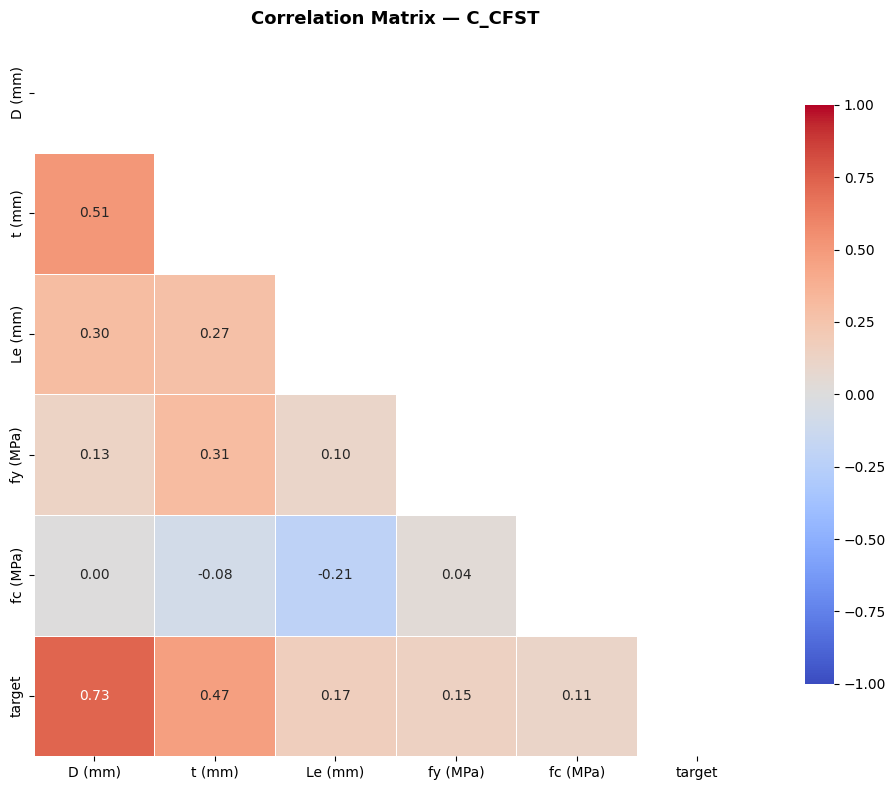


Correlation Analysis: C_CFST_BC

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  D (mm)                  0.735    0.735
  t (mm)                  0.388    0.388
  fc (MPa)                0.376    0.376
  fy (MPa)                0.201    0.201
  et (mm)                 0.052    0.052
  Le (mm)                 0.040    0.040 ⚠️ low
  eb (mm)                 0.033    0.033 ⚠️ low

  ⚠️  Low correlation features (<0.05):
  ['Le (mm)', 'eb (mm)']
  → Consider dropping BUT verify with domain knowledge

  ✓ No multicollinearity detected


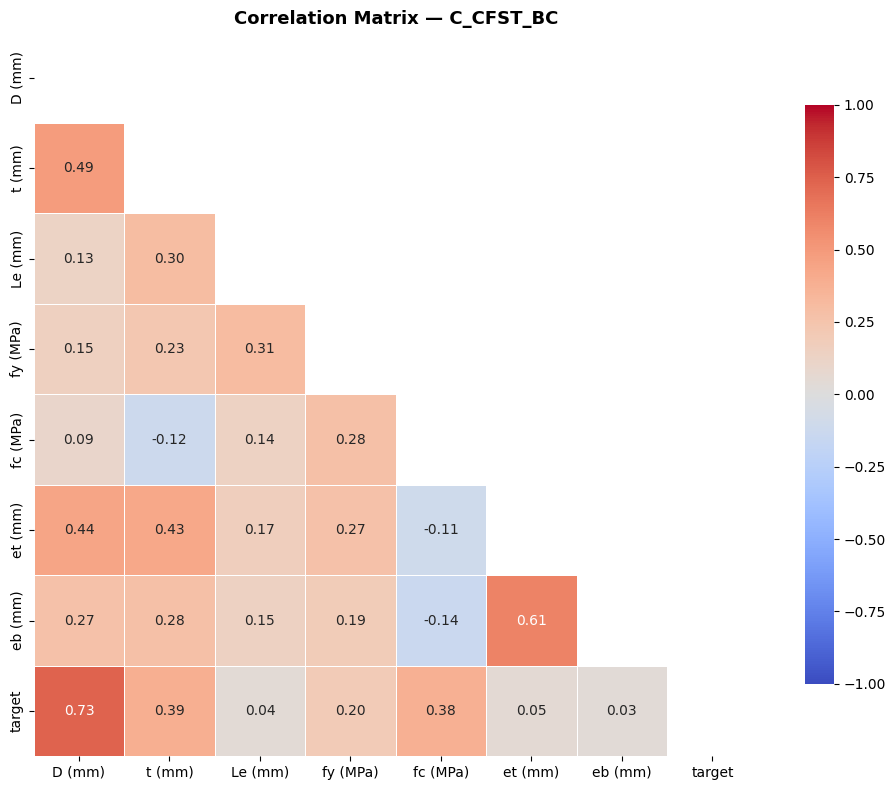


Correlation Analysis: R_CFST

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  B (mm)                  0.655    0.655
  t (mm)                  0.621    0.621
  H (mm)                  0.598    0.598
  fy (MPa)                0.542    0.542
  fc (MPa)                0.502    0.502
  Le (mm)                -0.021    0.021 ⚠️ low

  ⚠️  Low correlation features (<0.05):
  ['Le (mm)']
  → Consider dropping BUT verify with domain knowledge

  ✓ No multicollinearity detected


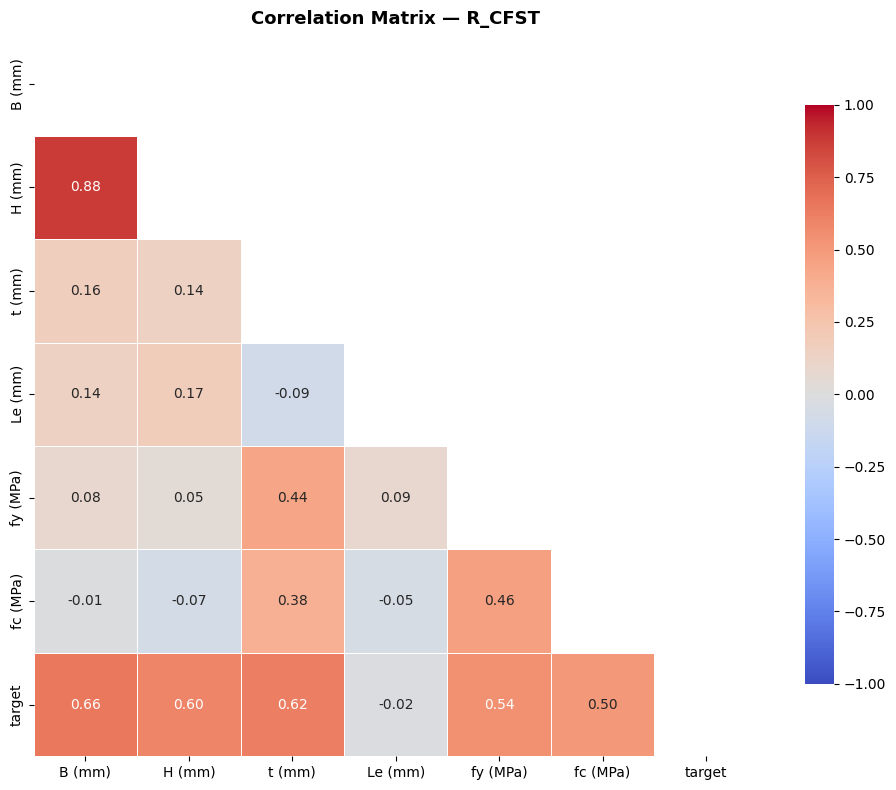


Correlation Analysis: R_CFST_BC

  Feature-Target Correlations:
  Feature                  Corr   |Corr|
  --------------------------------------
  H (mm)                  0.599    0.599
  B (mm)                  0.592    0.592
  t (mm)                  0.384    0.384
  fy (MPa)                0.383    0.383
  fc (MPa)                0.376    0.376
  et (mm)                -0.137    0.137
  Le (mm)                -0.135    0.135
  eb (mm)                -0.019    0.019 ⚠️ low

  ⚠️  Low correlation features (<0.05):
  ['eb (mm)']
  → Consider dropping BUT verify with domain knowledge

  ✓ No multicollinearity detected


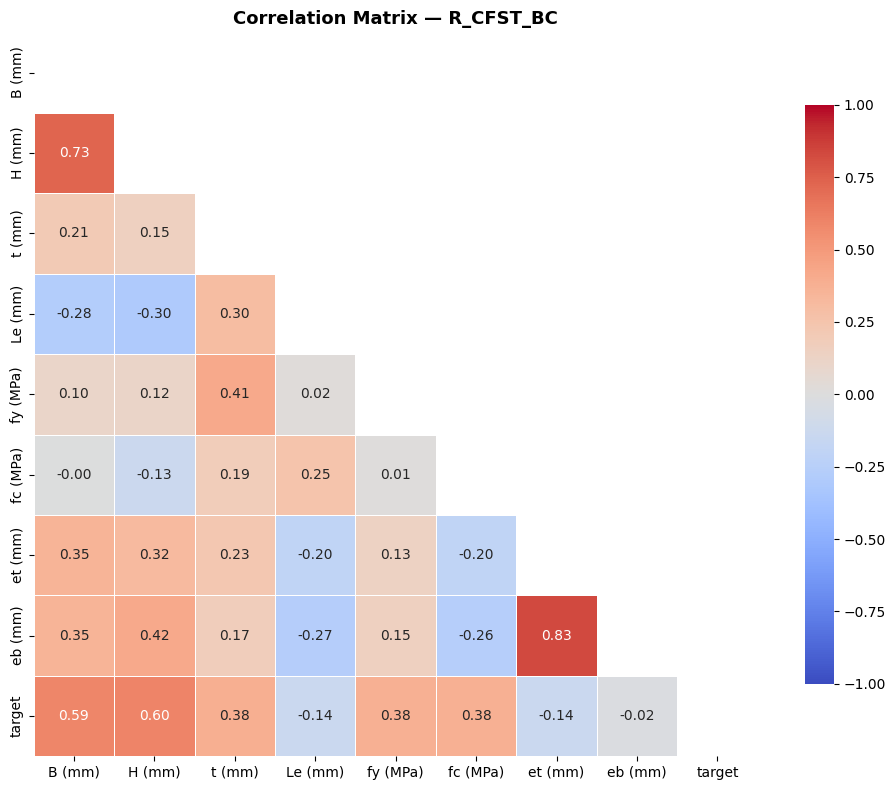

In [ ]:

import seaborn as sns

def analyze_correlations(processed_data, threshold_low=0.05,
                          threshold_high=0.95):


    for sheet, data in processed_data.items():
        X = data['X']
        y = data['y']

        df_full = X.copy()
        df_full['target'] = y.values

        corr_matrix = df_full.corr()

        print(f"\n{'='*55}")
        print(f"Correlation Analysis: {sheet}")
        print(f"{'='*55}")

        target_corr = corr_matrix['target'].drop('target')
        target_corr_abs = target_corr.abs().sort_values(
            ascending=False)

        print(f"\n  Feature-Target Correlations:")
        print(f"  {'Feature':<20} {'Corr':>8} {'|Corr|':>8}")
        print(f"  {'-'*38}")
        for feat, val in target_corr.abs().sort_values(
                ascending=False).items():
            raw = target_corr[feat]
            flag = " ⚠️ low" if val < threshold_low else ""
            print(f"  {feat:<20} {raw:>8.3f} {val:>8.3f}{flag}")

        low_corr_feats = target_corr_abs[
            target_corr_abs < threshold_low
        ].index.tolist()

        if low_corr_feats:
            print(f"\n  ⚠️  Low correlation features (<{threshold_low}):")
            print(f"  {low_corr_feats}")
            print(f"  → Consider dropping BUT verify with domain knowledge")

        feat_corr = corr_matrix.drop('target', axis=0).drop(
            'target', axis=1)

        high_pairs = []
        for i in range(len(feat_corr.columns)):
            for j in range(i+1, len(feat_corr.columns)):
                val = abs(feat_corr.iloc[i, j])
                if val > threshold_high:
                    high_pairs.append((
                        feat_corr.columns[i],
                        feat_corr.columns[j],
                        round(val, 3)
                    ))

        if high_pairs:
            print(f"\n  🔴 High correlation pairs (>{threshold_high}):")
            for f1, f2, v in high_pairs:
                print(f"     {f1} ↔ {f2}: {v}")
        else:
            print(f"\n  ✓ No multicollinearity detected")

        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix, mask=mask,
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}
        )
        plt.title(f'Correlation Matrix — {sheet}',
                  fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'/content/corr_{sheet}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

analyze_correlations(processed_data)

### **Fixing**

**⚠️NOTE**

Low correlation does not imply low importance. Pearson correlation measures only linear relationships, whereas some features may influence the target through non-linear interactions that are captured by machine learning models.

## **Feature Engineering**

In [ ]:


def add_engineering_features(processed_data):

    print("="*55)
    print("ADDING ENGINEERED FEATURES")
    print("="*55)

    for sheet, data in processed_data.items():
        X = data['X'].copy()
        added = []

        # ── Circular sections ─────────────────────────────
        if 'D (mm)' in X.columns and 't (mm)' in X.columns:
            X['D_t_ratio'] = X['D (mm)'] / X['t (mm)']
            added.append('D_t_ratio (slenderness)')

        if 'Le (mm)' in X.columns and 'D (mm)' in X.columns:
            X['L_D_ratio'] = X['Le (mm)'] / X['D (mm)']
            added.append('L_D_ratio (global slenderness)')

        if 'D (mm)' in X.columns:
            X['area_approx'] = np.pi * (X['D (mm)'] / 2) ** 2
            added.append('area_approx (cross-section area)')

        # ── Rectangular sections ──────────────────────────
        if 'B (mm)' in X.columns and 't (mm)' in X.columns:
            X['B_t_ratio'] = X['B (mm)'] / X['t (mm)']
            added.append('B_t_ratio (slenderness)')

        if 'H (mm)' in X.columns and 't (mm)' in X.columns:
            X['H_t_ratio'] = X['H (mm)'] / X['t (mm)']
            added.append('H_t_ratio (slenderness)')

        if 'Le (mm)' in X.columns and 'B (mm)' in X.columns:
            X['L_B_ratio'] = X['Le (mm)'] / X['B (mm)']
            added.append('L_B_ratio (global slenderness)')

        if 'B (mm)' in X.columns and 'H (mm)' in X.columns:
            X['area_approx'] = X['B (mm)'] * X['H (mm)']
            added.append('area_approx (cross-section area)')

        # ── All sections ──────────────────────────────────
        if 'fy (MPa)' in X.columns and 'fc (MPa)' in X.columns:
            X['fy_fc_ratio'] = X['fy (MPa)'] / X['fc (MPa)']
            added.append('fy_fc_ratio (strength ratio)')

        # ── Beam-column only (لو فيه eccentricity) ───────
        if 'et (mm)' in X.columns and 'eb (mm)' in X.columns:
            X['e_avg'] = (X['et (mm)'] + X['eb (mm)']) / 2
            added.append('e_avg (average eccentricity)')

        # حفظ في processed_data
        processed_data[sheet]['X'] = X

        print(f"\n✓ {sheet}:")
        print(f"  Features before: {len(data['X'].columns)}")
        print(f"  Features after:  {len(X.columns)}")
        for feat in added:
            print(f"    + {feat}")

    print("\n" + "="*55)
    print("✅ Engineering features added to processed_data")
    print("="*55)

add_engineering_features(processed_data)

for sheet, data in processed_data.items():
    print(f"{sheet}: {list(data['X'].columns)}")

ADDING ENGINEERED FEATURES

✓ C_CFST:
  Features before: 9
  Features after:  9
    + D_t_ratio (slenderness)
    + L_D_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)

✓ C_CFST_BC:
  Features before: 12
  Features after:  12
    + D_t_ratio (slenderness)
    + L_D_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)
    + e_avg (average eccentricity)

✓ R_CFST:
  Features before: 11
  Features after:  11
    + B_t_ratio (slenderness)
    + H_t_ratio (slenderness)
    + L_B_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)

✓ R_CFST_BC:
  Features before: 14
  Features after:  14
    + B_t_ratio (slenderness)
    + H_t_ratio (slenderness)
    + L_B_ratio (global slenderness)
    + area_approx (cross-section area)
    + fy_fc_ratio (strength ratio)
    + e_avg (average eccentricity)

✅ Engineering features added to processed_data
C_CFST:

## **Data Transformation**

### **Data Info**

In [ ]:
for sheet, data in processed_data.items():

    X = data['X']

    print("\n" + "="*70)
    print(sheet)
    print("="*70)

    print("\nShape:")
    print(X.shape)

    print("\nData Types:")
    print(X.dtypes)

    print("\nUnique Values:")
    for col in X.columns:
        if X[col].nunique() <= 10:
            print(f"{col}: {sorted(X[col].unique())}")

    print("\nSummary:")
    print(X.describe().T[['min','max','mean','std']])


C_CFST

Shape:
(1232, 9)

Data Types:
D (mm)         float64
t (mm)         float64
Le (mm)        float64
fy (MPa)       float64
fc (MPa)       float64
D_t_ratio      float64
L_D_ratio      float64
area_approx    float64
fy_fc_ratio    float64
dtype: object

Unique Values:

Summary:
                   min        max       mean       std
D (mm)        3.816613   6.928538   4.935460  0.488256
t (mm)        0.418710   2.864484   1.579977  0.427769
Le (mm)       5.032718   8.623533   6.630841  0.794405
fy (MPa)      5.188949   6.749931   5.793752  0.234928
fc (MPa)      2.319365   5.269403   3.785730  0.515780
D_t_ratio     1.739019  11.022227   3.372338  1.130942
L_D_ratio     0.964147   1.856860   1.351756  0.178850
area_approx  11.440529  37.702753  19.318411  3.918087
fy_fc_ratio   1.103302   2.452245   1.558395  0.219261

C_CFST_BC

Shape:
(482, 12)

Data Types:
D (mm)         float64
t (mm)         float64
Le (mm)        float64
fy (MPa)       float64
fc (MPa)       float64
et (mm)

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaled_data = {}

for sheet, data in processed_data.items():
    X = data['X'].copy()
    y = data['y']

    cols = X.columns

    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=cols, index=X.index)

    scaled_data[sheet] = {'X': X_scaled, 'y': y}

    print(f"✓ {sheet}: Scaling complete. Shape: {X_scaled.shape}")

print("\nSample of Scaled Data (First 5 rows of C_CFST):")
print(scaled_data['C_CFST']['X'].head())

✓ C_CFST: Scaling complete. Shape: (1232, 9)
✓ C_CFST_BC: Scaling complete. Shape: (482, 12)
✓ R_CFST: Scaling complete. Shape: (979, 11)
✓ R_CFST_BC: Scaling complete. Shape: (370, 14)

Sample of Scaled Data (First 5 rows of C_CFST):
     D (mm)    t (mm)   Le (mm)  fy (MPa)  fc (MPa)  D_t_ratio  L_D_ratio  \
0  0.588565 -0.678312 -0.640798 -0.246660 -1.173677   0.990254  -0.660542   
1  0.588565 -0.678312 -0.640798 -0.246660 -0.240842   0.990254  -0.660542   
2  0.594706 -0.690084 -0.640798  0.135260 -0.142987   1.009866  -0.662998   
3  0.594706 -0.690084 -0.640798  0.135260 -0.266334   1.009866  -0.662998   
4  0.582406 -0.178163 -0.640798 -0.408852 -0.606230   0.369067  -0.658075   

   area_approx  fy_fc_ratio  
0     0.596070     1.205787  
1     0.596070     0.126597  
2     0.602467     0.132990  
3     0.602467     0.251642  
4     0.589658     0.455850  


## **Save Steps**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib
import os

SAVE_DIR = '/content/drive/MyDrive/Master/Final/Preprocessing'
os.makedirs(SAVE_DIR, exist_ok=True)


saved_processors = {}

for sheet, data in processed_data.items():
    X = data['X'].copy()

    scaler = RobustScaler()
    X_scaled_values = scaler.fit_transform(X)

    saved_processors[sheet] = {
        'scaler': scaler,
        'columns': X.columns.tolist()
    }

    print(f"✓ Saved processor for {sheet}")

joblib.dump(saved_processors, os.path.join(SAVE_DIR, 'preprocessing_artifacts.pkl'))
print(f"\n✅ Preprocessing artifacts saved at: {SAVE_DIR}/preprocessing_artifacts.pkl")

✓ Saved processor for C_CFST
✓ Saved processor for C_CFST_BC
✓ Saved processor for R_CFST
✓ Saved processor for R_CFST_BC

✅ Preprocessing artifacts saved at: /content/drive/MyDrive/Master/Final/Preprocessing/preprocessing_artifacts.pkl


# **Baseline Models**




## Evaluation Function

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_model(model, X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {"Model": model_name, "RMSE": rmse, "R2": r2}

results = []

## **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

for sheet, data in scaled_data.items():
    model = LinearRegression()
    res = evaluate_model(model, data['X'], data['y'], "Linear Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Linear Regression: R2 = {res['R2']:.4f}")

[C_CFST] Linear Regression: R2 = 0.8504
[C_CFST_BC] Linear Regression: R2 = 0.8707
[R_CFST] Linear Regression: R2 = 0.8625
[R_CFST_BC] Linear Regression: R2 = 0.8097


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

for sheet, data in scaled_data.items():
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Random Forest")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Random Forest: R2 = {res['R2']:.4f}")

[C_CFST] Random Forest: R2 = 0.9868
[C_CFST_BC] Random Forest: R2 = 0.7724
[R_CFST] Random Forest: R2 = 0.9305
[R_CFST_BC] Random Forest: R2 = 0.9242


## **ْْXGBoost**

In [ ]:
from xgboost import XGBRegressor

for sheet, data in scaled_data.items():
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "XGBoost")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] XGBoost: R2 = {res['R2']:.4f}")

[C_CFST] XGBoost: R2 = 0.9942
[C_CFST_BC] XGBoost: R2 = 0.7903
[R_CFST] XGBoost: R2 = 0.9571
[R_CFST_BC] XGBoost: R2 = 0.9777


## **AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

for sheet, data in scaled_data.items():
    model = AdaBoostRegressor(n_estimators=100, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "AdaBoost")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] AdaBoost: R2 = {res['R2']:.4f}")

[C_CFST] AdaBoost: R2 = 0.8620
[C_CFST_BC] AdaBoost: R2 = 0.7589
[R_CFST] AdaBoost: R2 = 0.8550
[R_CFST_BC] AdaBoost: R2 = 0.7906


## **Voting Regressor**

In [ ]:
from sklearn.ensemble import VotingRegressor

for sheet, data in scaled_data.items():
    r1 = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model = VotingRegressor([('rf', r1), ('xgb', r2)])

    res = evaluate_model(model, data['X'], data['y'], "Voting (RF+XGB)")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Voting Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Voting Regressor: R2 = 0.9930
[C_CFST_BC] Voting Regressor: R2 = 0.7831
[R_CFST] Voting Regressor: R2 = 0.9497
[R_CFST_BC] Voting Regressor: R2 = 0.9676


## **Stacking Regressor**

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

for sheet, data in scaled_data.items():
    estimators = [('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
                  ('xgb', XGBRegressor(n_estimators=100, random_state=42))]
    model = StackingRegressor(estimators=estimators, final_estimator=Ridge())

    res = evaluate_model(model, data['X'], data['y'], "Stacking")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Stacking: R2 = {res['R2']:.4f}")

[C_CFST] Stacking: R2 = 0.9946
[C_CFST_BC] Stacking: R2 = 0.7948
[R_CFST] Stacking: R2 = 0.9600
[R_CFST_BC] Stacking: R2 = 0.9633


## **Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

for sheet, data in scaled_data.items():
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Gradient Boosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Gradient Boosting: R2 = {res['R2']:.4f}")

[C_CFST] Gradient Boosting: R2 = 0.9909
[C_CFST_BC] Gradient Boosting: R2 = 0.8640
[R_CFST] Gradient Boosting: R2 = 0.9417
[R_CFST_BC] Gradient Boosting: R2 = 0.9477


## **Support Vector Regressor (SVR)**

In [ ]:
from sklearn.svm import SVR

for sheet, data in scaled_data.items():
    # C هو معامل التنظيم، و gamma تتحكم في مدى تأثير البيانات
    model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
    res = evaluate_model(model, data['X'], data['y'], "SVR (RBF)")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] SVR (RBF): R2 = {res['R2']:.4f}")

[C_CFST] SVR (RBF): R2 = 0.3556
[C_CFST_BC] SVR (RBF): R2 = 0.3660
[R_CFST] SVR (RBF): R2 = 0.6724
[R_CFST_BC] SVR (RBF): R2 = 0.7007


## **HistGradientBoostingRegressor**

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

for sheet, data in scaled_data.items():
    model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "HistGradientBoosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] HistGradientBoosting: R2 = {res['R2']:.4f}")

[C_CFST] HistGradientBoosting: R2 = 0.9848
[C_CFST_BC] HistGradientBoosting: R2 = 0.9513
[R_CFST] HistGradientBoosting: R2 = 0.9503
[R_CFST_BC] HistGradientBoosting: R2 = 0.8379


## **MLPRegressor**

In [ ]:
from sklearn.neural_network import MLPRegressor

for sheet, data in scaled_data.items():
    # hidden_layer_sizes=(100, 50) تعني طبقتين: الأولى بها 100 عصب والثانية 50
    # max_iter=500 لضمان وصول الموديل للتقارب (Convergence)
    model = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )

    res = evaluate_model(model, data['X'], data['y'], "MLP Regressor")
    res['Sheet'] = sheet
    results.append(res)

    print(f"[{sheet}] MLP Regressor: R2 = {res['R2']:.4f}")

[C_CFST] MLP Regressor: R2 = 0.8371
[C_CFST_BC] MLP Regressor: R2 = 0.9279
[R_CFST] MLP Regressor: R2 = 0.9174
[R_CFST_BC] MLP Regressor: R2 = 0.7959


## **K-Nearest Neighbors (KNN)**

In [ ]:

from sklearn.neighbors import KNeighborsRegressor

for sheet, data in scaled_data.items():
    model = KNeighborsRegressor(n_neighbors=5, weights='uniform')
    res = evaluate_model(model, data['X'], data['y'], "K-Nearest Neighbors")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] K-Nearest Neighbors: R2 = {res['R2']:.4f}")

[C_CFST] K-Nearest Neighbors: R2 = 0.9729
[C_CFST_BC] K-Nearest Neighbors: R2 = 0.9123
[R_CFST] K-Nearest Neighbors: R2 = 0.9005
[R_CFST_BC] K-Nearest Neighbors: R2 = 0.8528


## **Lasso Regression**


In [ ]:
from sklearn.linear_model import Lasso

for sheet, data in scaled_data.items():
    model = Lasso(alpha=1.0, random_state=42, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "Lasso Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Lasso Regression: R2 = {res['R2']:.4f}")

[C_CFST] Lasso Regression: R2 = 0.8519
[C_CFST_BC] Lasso Regression: R2 = 0.8522
[R_CFST] Lasso Regression: R2 = 0.8617
[R_CFST_BC] Lasso Regression: R2 = 0.8056


## **Ridge Regression**


In [ ]:
from sklearn.linear_model import Ridge

for sheet, data in scaled_data.items():
    model = Ridge(alpha=1.0, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Ridge Regression")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Ridge Regression: R2 = {res['R2']:.4f}")

[C_CFST] Ridge Regression: R2 = 0.8483
[C_CFST_BC] Ridge Regression: R2 = 0.8104
[R_CFST] Ridge Regression: R2 = 0.8618
[R_CFST_BC] Ridge Regression: R2 = 0.8048


## **ElasticNet**


In [ ]:
from sklearn.linear_model import ElasticNet

for sheet, data in scaled_data.items():
    model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "ElasticNet")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] ElasticNet: R2 = {res['R2']:.4f}")

[C_CFST] ElasticNet: R2 = 0.5569
[C_CFST_BC] ElasticNet: R2 = 0.6079
[R_CFST] ElasticNet: R2 = 0.8387
[R_CFST_BC] ElasticNet: R2 = 0.7523


## **SGD Regressor**


In [ ]:
from sklearn.linear_model import SGDRegressor

for sheet, data in scaled_data.items():
    model = SGDRegressor(max_iter=10000, tol=1e-3, random_state=42, penalty='l2')
    res = evaluate_model(model, data['X'], data['y'], "SGD Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] SGD Regressor: R2 = {res['R2']:.4f}")

[C_CFST] SGD Regressor: R2 = 0.8346
[C_CFST_BC] SGD Regressor: R2 = 0.7635
[R_CFST] SGD Regressor: R2 = 0.8547
[R_CFST_BC] SGD Regressor: R2 = 0.7985


## **Decision Tree**


In [ ]:
from sklearn.tree import DecisionTreeRegressor

for sheet, data in scaled_data.items():
    model = DecisionTreeRegressor(max_depth=10, random_state=42)
    res = evaluate_model(model, data['X'], data['y'], "Decision Tree")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Decision Tree: R2 = {res['R2']:.4f}")

[C_CFST] Decision Tree: R2 = 0.9734
[C_CFST_BC] Decision Tree: R2 = 0.7103
[R_CFST] Decision Tree: R2 = 0.9162
[R_CFST_BC] Decision Tree: R2 = 0.4892


## **ExtraTrees Regressor**


In [ ]:


from sklearn.ensemble import ExtraTreesRegressor

for sheet, data in scaled_data.items():
    model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    res = evaluate_model(model, data['X'], data['y'], "ExtraTrees Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] ExtraTrees Regressor: R2 = {res['R2']:.4f}")


[C_CFST] ExtraTrees Regressor: R2 = 0.9938
[C_CFST_BC] ExtraTrees Regressor: R2 = 0.9257
[R_CFST] ExtraTrees Regressor: R2 = 0.9674
[R_CFST_BC] ExtraTrees Regressor: R2 = 0.9680


## **Bagging Regressor**


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

for sheet, data in scaled_data.items():
    base_estimator = DecisionTreeRegressor(max_depth=10, random_state=42)
    model = BaggingRegressor(estimator=base_estimator, n_estimators=100, random_state=42, n_jobs=-1)
    res = evaluate_model(model, data['X'], data['y'], "Bagging Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Bagging Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Bagging Regressor: R2 = 0.9867
[C_CFST_BC] Bagging Regressor: R2 = 0.7701
[R_CFST] Bagging Regressor: R2 = 0.9301
[R_CFST_BC] Bagging Regressor: R2 = 0.9164


## **Huber Regressor**


In [ ]:

from sklearn.linear_model import HuberRegressor

for sheet, data in scaled_data.items():
    model = HuberRegressor(epsilon=1.35, max_iter=10000)
    res = evaluate_model(model, data['X'], data['y'], "Huber Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Huber Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Huber Regressor: R2 = 0.8316
[C_CFST_BC] Huber Regressor: R2 = 0.6934
[R_CFST] Huber Regressor: R2 = 0.8526
[R_CFST_BC] Huber Regressor: R2 = 0.8410


## **Theil-Sen Regressor**


In [ ]:
from sklearn.linear_model import TheilSenRegressor

for sheet, data in scaled_data.items():
    model = TheilSenRegressor(random_state=42, n_jobs=-1, max_subpopulation=10000)
    res = evaluate_model(model, data['X'], data['y'], "Theil-Sen Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Theil-Sen Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Theil-Sen Regressor: R2 = 0.7956
[C_CFST_BC] Theil-Sen Regressor: R2 = 0.6882
[R_CFST] Theil-Sen Regressor: R2 = 0.8423
[R_CFST_BC] Theil-Sen Regressor: R2 = 0.8550


## **Poisson Regressor**


In [ ]:
from sklearn.linear_model import PoissonRegressor

for sheet, data in scaled_data.items():
    model = PoissonRegressor(max_iter=10000, alpha=1.0)
    res = evaluate_model(model, data['X'], data['y'], "Poisson Regressor")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Poisson Regressor: R2 = {res['R2']:.4f}")

[C_CFST] Poisson Regressor: R2 = 0.9844
[C_CFST_BC] Poisson Regressor: R2 = 0.9004
[R_CFST] Poisson Regressor: R2 = 0.9315
[R_CFST_BC] Poisson Regressor: R2 = 0.7036


## **Categorical Boosting (CatBoost)**


In [ ]:
!pip install catboost -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [ ]:


from catboost import CatBoostRegressor

for sheet, data in scaled_data.items():
    model = CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=False
    )
    res = evaluate_model(model, data['X'], data['y'], "Categorical Boosting")
    res['Sheet'] = sheet
    results.append(res)
    print(f"[{sheet}] Categorical Boosting (CatBoost): R2 = {res['R2']:.4f}")

[C_CFST] Categorical Boosting (CatBoost): R2 = 0.9921
[C_CFST_BC] Categorical Boosting (CatBoost): R2 = 0.7831
[R_CFST] Categorical Boosting (CatBoost): R2 = 0.9536
[R_CFST_BC] Categorical Boosting (CatBoost): R2 = 0.9474


## **ِALL RESULTS**

In [ ]:
df_results = pd.DataFrame(results)
print(df_results.sort_values(by=['Sheet', 'R2'], ascending=[True, False]))


                   Model        RMSE        R2      Sheet
20              Stacking  231.926322  0.994592     C_CFST
8                XGBoost  240.293215  0.994195     C_CFST
64  ExtraTrees Regressor  247.443526  0.993845     C_CFST
16       Voting (RF+XGB)  262.940744  0.993049     C_CFST
84  Categorical Boosting  279.593657  0.992141     C_CFST
..                   ...         ...       ...        ...
15              AdaBoost  378.894362  0.790612  R_CFST_BC
55            ElasticNet  412.112227  0.752288  R_CFST_BC
83     Poisson Regressor  450.770734  0.703635  R_CFST_BC
31             SVR (RBF)  453.014699  0.700677  R_CFST_BC
63         Decision Tree  591.814910  0.489156  R_CFST_BC

[88 rows x 4 columns]


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)

print("\n" + "="*75)
print(" " * 20 + "BASELINE MODELS RESULTS")
print("="*75)

for sheet in sorted(df_results['Sheet'].unique()):
    sheet_df = df_results[df_results['Sheet'] == sheet].copy()
    sheet_df = sheet_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    sheet_df['Rank'] = range(1, len(sheet_df) + 1)

    print(f"\n{'─'*75}")
    print(f"    {sheet}")
    print(f"{'─'*75}")

    print(f"{'Rank':<6} {'Model':<28} {'R²':>12} {'RMSE':>12}")
    print(f"{'─'*6} {'─'*28} {'─'*12} {'─'*12}")

    for _, row in sheet_df.iterrows():
        rank = int(row['Rank'])
        model = row['Model'][:27]
        r2 = row['R2']
        rmse = row['RMSE']

        if rank == 1:
            prefix = "🥇"
        elif rank == 2:
            prefix = "🥈"
        elif rank == 3:
            prefix = "🥉"
        else:
            prefix = "  "

        print(f"{prefix} {rank:<3} {model:<28} {r2:>12.6f} {rmse:>12.2f}")

    print(f"{'─'*75}")
    print(f"  Best Model: {sheet_df.iloc[0]['Model']} (R² = {sheet_df.iloc[0]['R2']:.6f})")

print("\n" + "="*75)


                    BASELINE MODELS RESULTS

───────────────────────────────────────────────────────────────────────────
    C_CFST
───────────────────────────────────────────────────────────────────────────
Rank   Model                                  R²         RMSE
────── ──────────────────────────── ──────────── ────────────
🥇 1   Stacking                         0.994592       231.93
🥈 2   XGBoost                          0.994195       240.29
🥉 3   ExtraTrees Regressor             0.993845       247.44
   4   Voting (RF+XGB)                  0.993049       262.94
   5   Categorical Boosting             0.992141       279.59
   6   Gradient Boosting                0.990866       301.43
   7   Random Forest                    0.986817       362.12
   8   Bagging Regressor                0.986728       363.35
   9   HistGradientBoosting             0.984756       389.40
   10  Poisson Regressor                0.984438       393.44
   11  Decision Tree                    0.973386  

| Model                | C_CFST (R²) | C_CFST_BC (R²) | R_CFST (R²) | R_CFST_BC (R²) |
| -------------------- | ----------: | -------------: | ----------: | -------------: |
| Linear Regression    |    0.850392 |       0.870703 |    0.862536 |       0.809691 |
| Random Forest        |    0.986817 |       0.772375 |    0.930540 |       0.924180 |
| XGBoost              |    0.994195 |       0.790305 |    0.957093 |       0.977673 |
| AdaBoost             |    0.861960 |       0.758907 |    0.855037 |       0.790612 |
| Voting (RF+XGB)      |    0.993049 |       0.783051 |    0.949711 |       0.967620 |
| Stacking             |    0.994592 |       0.794779 |    0.960037 |       0.963273 |
| Gradient Boosting    |    0.990866 |       0.863954 |    0.941657 |       0.947682 |
| SVR (RBF)            |    0.355626 |       0.365951 |    0.672417 |       0.700677 |
| HistGradientBoosting |    0.984756 |       0.951256 |    0.950261 |       0.837870 |
| MLP Regressor        |    0.837144 |       0.927920 |    0.917425 |       0.795944 |


# **ACTUAL TRAINING**

## **Sheet 1) C_CFST**


*   XGBoost
*   List item



### **setup**

In [ ]:

!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'C_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.5 MB/s eta 0:00:00
Dataset: C_CFST
Samples: 1232  Features: 9


### **Model 1: XGBoost + Nested CV + Optuna**

In [ ]:

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':     trial.suggest_int(
                                            'n_estimators', 100, 1200),
                    'learning_rate':    trial.suggest_float(
                                            'learning_rate', 0.005, 0.3,
                                            log=True),
                    'max_depth':        trial.suggest_int(
                                            'max_depth', 3, 12),
                    'subsample':        trial.suggest_float(
                                            'subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float(
                                            'colsample_bytree', 0.5, 1.0),
                    'reg_alpha':        trial.suggest_float(
                                            'reg_alpha', 1e-8, 10.0,
                                            log=True),
                    'reg_lambda':       trial.suggest_float(
                                            'reg_lambda', 1e-8, 10.0,
                                            log=True),
                    'min_child_weight': trial.suggest_int(
                                            'min_child_weight', 1, 10),
                    'gamma':            trial.suggest_float(
                                            'gamma', 1e-8, 1.0,
                                            log=True),
                    'random_state': RANDOM_STATE, 'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }


### **Model 2: Stacking (RF + Tuned XGBoost) + Nested CV**

In [ ]:

def run_stacking_nested_cv(X, y, xgb_best_params,
                            label='Stacking'):
    """
    Stacking: RF + Tuned XGBoost → Ridge meta-learner
    بنستخدم أفضل params من Model 1 للـ XGBoost
    """
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # RF params بنعمل tuning بسيط عليها
        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int(
                                        'n_estimators', 100, 500),
                    'max_depth':    trial.suggest_int(
                                        'max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int(
                                             'min_samples_split', 2, 10),
                    'max_features': trial.suggest_float(
                                        'max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })

        # بناء الـ Stacking
        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        stack = StackingRegressor(
            estimators      = estimators,
            final_estimator = Ridge(alpha=1.0),
            cv              = 3,
            n_jobs          = -1,
        )
        stack.fit(X_tr, y_tr)
        y_pred = stack.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':     label,
        'R2_Mean':   round(np.mean(outer_r2),   4),
        'R2_Std':    round(np.std(outer_r2),    4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std':  round(np.std(outer_rmse),  2),
        'MAE':       round(np.mean(outer_mae),  2),
        'MAPE':      round(np.mean(outer_mape), 2),
    }

### **Execution**

In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

# 1. XGBoost
xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

# 2. Stacking بأفضل params من XGBoost
stack_result = run_stacking_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Stacking (RF + XGB)'
)


#######################################################
# SHEET: C_CFST
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9952  RMSE=217.5  depth=6
  Fold 2: R²=0.9669  RMSE=1039.1  depth=4
  Fold 3: R²=0.9965  RMSE=183.4  depth=4
  Fold 4: R²=0.9925  RMSE=357.9  depth=7
  Fold 5: R²=0.9927  RMSE=300.9  depth=4

  ✓ XGBoost:
    R²   = 0.9888 ± 0.0110
    RMSE = 419.75 ± 315.70
    MAE  = 145.18
    MAPE = 7.77%

Stacking (RF + XGB) — Nested CV
  Fold 1: R²=0.8895  RMSE=1048.4
  Fold 2: R²=0.9508  RMSE=1268.1
  Fold 3: R²=0.9357  RMSE=785.1
  Fold 4: R²=0.8922  RMSE=1359.7
  Fold 5: R²=0.8950  RMSE=1139.3

  ✓ Stacking (RF + XGB):
    R²   = 0.9126 ± 0.0255
    RMSE = 1120.15 ± 198.50
    MAE  = 505.91
    MAPE = 42.58%


### **RESULTS**

In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, stack_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          stack_result['R2_Mean'] else stack_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")


FINAL COMPARISON — C_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9888 ± 0.0110     419.8    145.2    7.77%
Stacking (RF + XGB)    0.9126 ± 0.0255    1120.2    505.9   42.58%

✓ Winner for C_CFST: XGBoost (R²=0.9888)


### **Save**

In [ ]:
import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف (إذا لم يكن مربوطاً بالفعل)
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler (ضروري جداً لأي تنبؤ مستقبلي)
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديلات النهائية على كامل البيانات (Full Data)
# ملاحظة: الموديلات في الـ Nested CV تدربت على أجزاء فقط،
# لذا يجب تدريب موديل نهائي على X و y بالكامل باستخدام أفضل Params

# أ. XGBoost النهائي
xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"✓ XGBoost final model saved.")

# ب. Stacking النهائي
# سنعيد بناءه بنفس الـ estimators التي استخدمناها في الـ Nested CV
rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE} # يفضل استخدام أفضل params لو قمتِ بتخزينها
stack_final = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    final_estimator=Ridge(),
    cv=3, n_jobs=-1
)
stack_final.fit(X, y)
joblib.dump(stack_final, os.path.join(BASE_DIR, 'Stacking_NestedCV.pkl'))
print(f"✓ Stacking final model saved.")

# 5. حفظ النتائج (Metrics) في ملف JSON للرجوع إليها لاحقاً
all_results = {
    "XGBoost": xgb_result,
    "Stacking": stack_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")
print(f"يمكنك الآن استخدام الموديلات المحفوظة في أي وقت لعمل SHAP أو Feature Importance.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

بدء عملية الحفظ في: /content/drive/MyDrive/Master/Final/C_CFST
✓ Scaler saved: /content/drive/MyDrive/Master/Final/C_CFST/scaler.pkl
✓ XGBoost final model saved.
✓ Stacking final model saved.

✅ تم حفظ جميع الملفات بنجاح في الدرايف!
يمكنك الآن استخدام الموديلات المحفوظة في أي وقت لعمل SHAP أو Feature Importance.


### **Train/Test split 70/30**

In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

# 1. الإعدادات الأساسية
SHEET = 'C_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
# تأكدي أن processed_data معرفة مسبقاً في الـ Notebook
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# 3. التقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# حفظ الـ Scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

print("جاري التدريب...")
model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- نتائج الأداء ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")

# 7. الحفظ النهائي
joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي في: {BASE_DIR}")

✓ تم تقسيم البيانات: 985 للتدريب، 247 للاختبار.
✓ تم حفظ الـ Scaler.
جاري التدريب...
✓ تم التدريب بنجاح.

--- نتائج الأداء ---
R² Score : 0.9927
RMSE     : 269.69

✅ تم حفظ الموديل النهائي في: /content/drive/MyDrive/Master/Final/C_CFST


#### **Feature Importance**

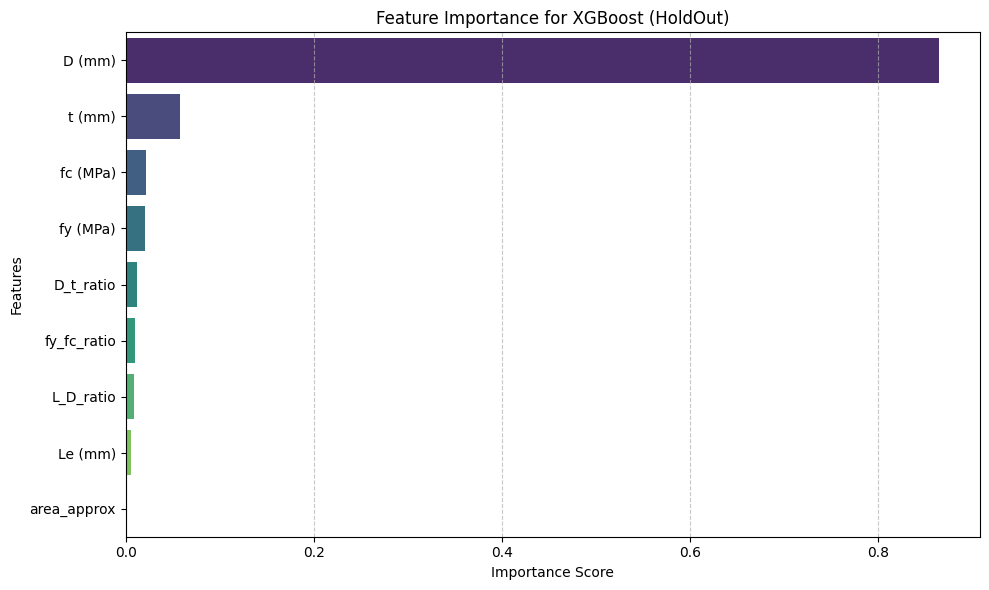

       Feature  Importance
0       D (mm)    0.864954
1       t (mm)    0.057538
4     fc (MPa)    0.021811
3     fy (MPa)    0.020613
5    D_t_ratio    0.011428
8  fy_fc_ratio    0.009591
6    L_D_ratio    0.008453
2      Le (mm)    0.005611
7  area_approx    0.000000


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد المسارات
BASE_DIR = '/content/drive/MyDrive/Master/Final/C_CFST'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')

# 2. تحميل الموديل والـ Scaler
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# 3. الحصول على أسماء الميزات (Features)
# نستخدم feature_names_in_ من الـ scaler لأننا تدربنا عليه سابقاً
if hasattr(loaded_scaler, 'feature_names_in_'):
    feature_names = loaded_scaler.feature_names_in_
else:
    # إذا لم تظهر الأسماء تلقائياً، يمكنك استبدال القائمة التالية بأسماء الأعمدة لديك
    feature_names = [f"Feature_{i}" for i in range(len(loaded_model.feature_importances_))]

# 4. تجهيز البيانات للرسم
importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# 5. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost (HoldOut)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# طباعة الترتيب في جدول
print(df_imp)

#### **SHAP analysis**

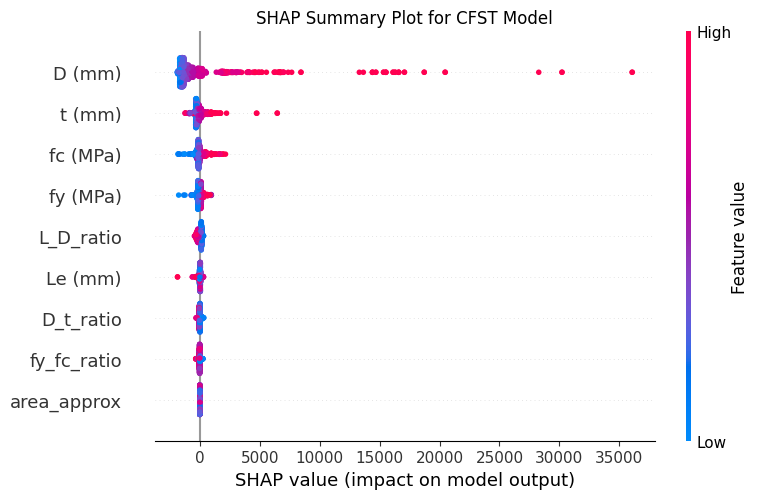

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt

# 1. تحميل الموديل والبيانات (بنفس الطريقة السابقة)
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)

# 2. تجهيز الـ Explainer
# نستخدم X_train_scaled لأن الموديل تدرب عليها
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_scaled)

# 3. الرسم البياني (Summary Plot)
# هذا الرسم هو "الذهب" في الأبحاث العلمية
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_scaled, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot for CFST Model")
plt.tight_layout()
plt.show()

"To enhance the interpretability of the XGBoost model, SHAP (SHapley Additive exPlanations) values were analyzed. As shown in the summary plot, the diameter ($D$) is the most influential feature on the model's output, exhibiting a strong positive correlation with the load-carrying capacity of the CFST columns. Features such as wall thickness ($t$), concrete compressive strength ($f_c$), and steel yield strength ($f_y$) show a moderate positive impact, which aligns with structural engineering principles. Conversely, slenderness-related parameters ($L/D$, $Le$) demonstrate a negligible influence on the model predictions within the current dataset range, suggesting that the model's predictive capability is primarily driven by the cross-sectional geometry rather than the column height for this specific dataset."

## **Sheet 2) C_CFST_BC**


*   HistGradientBoosting
*   MLP



### **setup**

In [ ]:

!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib, json, os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET          = 'C_CFST_BC'
RANDOM_STATE   = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

Dataset: C_CFST_BC
Samples: 482  Features: 12


### **Model 1: HistGradientBoosting + Nested CV + Optuna**

In [ ]:

def run_hgb_nested_cv(X, y, label='HistGradientBoosting'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'max_iter':        trial.suggest_int(
                                           'max_iter', 100, 1000),
                    'learning_rate':   trial.suggest_float(
                                           'learning_rate', 0.01, 0.3,
                                           log=True),
                    'max_depth':       trial.suggest_int(
                                           'max_depth', 3, 15),
                    'min_samples_leaf': trial.suggest_int(
                                            'min_samples_leaf', 10, 100),
                    'l2_regularization': trial.suggest_float(
                                             'l2_regularization', 1e-6, 10.0,
                                             log=True),
                    'max_bins':        trial.suggest_int(
                                           'max_bins', 64, 255),
                    'random_state': RANDOM_STATE,
                }
                m = HistGradientBoostingRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params['random_state'] = RANDOM_STATE
        model = HistGradientBoostingRegressor(**best_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Model 2: MLP + Nested CV + Optuna**

In [ ]:


def build_mlp(params):
    n_layers = params.get('n_layers', 2)
    layers   = tuple(
        params.get(f'units_{i}', 64)
        for i in range(n_layers)
    )
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes  = layers,
            activation          = params.get('activation', 'relu'),
            alpha               = params.get('alpha', 0.001),
            learning_rate_init  = params.get('lr_init', 0.001),
            batch_size          = params.get('batch_size', 32),
            max_iter            = 1000,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 20,
            random_state        = RANDOM_STATE,
        ))
    ])

def run_mlp_nested_cv(X, y, label='MLP'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_layers':   trial.suggest_int(
                                      'n_layers', 1, 4),
                    'activation': trial.suggest_categorical(
                                      'activation',
                                      ['relu', 'tanh']),
                    'alpha':      trial.suggest_float(
                                      'alpha', 1e-6, 0.1,
                                      log=True),
                    'lr_init':    trial.suggest_float(
                                      'lr_init', 1e-4, 0.05,
                                      log=True),
                    'batch_size': trial.suggest_categorical(
                                      'batch_size',
                                      [16, 32, 64, 128]),
                }
                for i in range(p['n_layers']):
                    p[f'units_{i}'] = trial.suggest_int(
                        f'units_{i}', 32, 256)
                m = build_mlp(p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        final_model = build_mlp(best_params)
        final_model.fit(X_tr, y_tr)
        y_pred = final_model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        arch = [best_params.get(f'units_{i}', 64)
                for i in range(best_params.get('n_layers', 2))]
        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"arch={arch}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }


### **Execution**

In [ ]:

print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

hgb_result = run_hgb_nested_cv(X, y,
                                label='HistGradientBoosting')
mlp_result = run_mlp_nested_cv(X, y,
                                label='MLP')



#######################################################
# SHEET: C_CFST_BC
#######################################################

HistGradientBoosting — Nested CV
  Fold 1: R²=0.9316  RMSE=249.3  depth=11
  Fold 2: R²=0.8633  RMSE=272.9  depth=11
  Fold 3: R²=0.8646  RMSE=264.6  depth=8
  Fold 4: R²=0.9528  RMSE=172.1  depth=5
  Fold 5: R²=0.9884  RMSE=86.6  depth=5

  ✓ HistGradientBoosting:
    R²   = 0.9201 ± 0.0493
    RMSE = 209.09 ± 70.91
    MAE  = 93.92
    MAPE = 14.37%

MLP — Nested CV
  Fold 1: R²=0.9864  RMSE=111.2  arch=[90, 181, 102, 149]
  Fold 2: R²=0.9862  RMSE=86.8  arch=[137, 136, 164, 33]
  Fold 3: R²=0.9811  RMSE=99.0  arch=[135, 104, 61, 68]
  Fold 4: R²=0.9280  RMSE=212.4  arch=[87, 236, 154, 212]
  Fold 5: R²=0.9741  RMSE=129.6  arch=[65, 165, 122, 74]

  ✓ MLP:
    R²   = 0.9712 ± 0.0220
    RMSE = 127.78 ± 44.61
    MAE  = 70.77
    MAPE = 11.99%


### **Results**

In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<25} {'R²':^22} {'RMSE':>8} "
      f"{'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [hgb_result, mlp_result]:
    print(f"{res['model']:<25} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (hgb_result if hgb_result['R2_Mean'] >=
          mlp_result['R2_Mean'] else mlp_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")


FINAL COMPARISON — C_CFST_BC
Model                               R²               RMSE      MAE   MAPE%
------------------------------------------------------------
HistGradientBoosting      0.9201 ± 0.0493     209.1     93.9   14.37%
MLP                       0.9712 ± 0.0220     127.8     70.8   11.99%

✓ Winner for C_CFST_BC: MLP (R²=0.9712)


### **Save**

In [ ]:

from google.colab import drive
drive.mount('/content/drive') if not os.path.exists(
    '/content/drive/MyDrive') else None

BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

# HGB النهائي
hgb_final = HistGradientBoostingRegressor(
    **hgb_result['best_params'])
hgb_final.fit(X, y)
joblib.dump(hgb_final,
            os.path.join(BASE_DIR,
                         'HistGradientBoosting_NestedCV.pkl'))
print(f"✓ HGB model saved")

# MLP النهائي
mlp_final = build_mlp(mlp_result['best_params'])
mlp_final.fit(X, y)
joblib.dump(mlp_final,
            os.path.join(BASE_DIR, 'MLP_NestedCV.pkl'))
print(f"✓ MLP model saved")

# النتايج
all_results = {
    'HistGradientBoosting': hgb_result,
    'MLP':                  mlp_result,
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"✓ Results saved")

✓ HGB model saved
✓ MLP model saved
✓ Results saved


### **Train/Test split 70/30**

In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. الإعدادات الأساسية
SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
# تأكدي أن X و y معرفة مسبقاً لهذا الشيت
X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

# 3. التقسيم (70/30 كما طلبتِ)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. بناء الموديل (مع البارامترات الأفضل التي حصلنا عليها)
# لاحظي: نحن نستخدم أفضل بارامترات من الـ Nested CV
best_p = mlp_result['best_params']

# تحويل البارامترات لتناسب MLPRegressor
n_layers = best_p.get('n_layers', 2)
layers = tuple(best_p.get(f'units_{i}', 64) for i in range(n_layers))

mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=layers,
        activation=best_p.get('activation', 'relu'),
        alpha=best_p.get('alpha', 0.001),
        learning_rate_init=best_p.get('lr_init', 0.001),
        batch_size=best_p.get('batch_size', 32),
        max_iter=1000,
        random_state=42
    ))
])

# 5. التدريب
print("جاري التدريب باستخدام أفضل بارامترات...")
mlp_model.fit(X_train, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = mlp_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- نتائج الأداء على مجموعة الاختبار ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

# 7. الحفظ النهائي
joblib.dump(mlp_model, os.path.join(BASE_DIR, 'MLP_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي (Pipeline) في: {BASE_DIR}")

✓ تم تقسيم البيانات: 337 للتدريب، 145 للاختبار.
جاري التدريب باستخدام أفضل بارامترات...
✓ تم التدريب بنجاح.

--- نتائج الأداء على مجموعة الاختبار ---
R² Score : 0.9885
RMSE     : 99.38
MAE      : 58.53

✅ تم حفظ الموديل النهائي (Pipeline) في: /content/drive/MyDrive/Master/Final/C_CFST_BC


### **Feature Importance (Permutation Importance)**

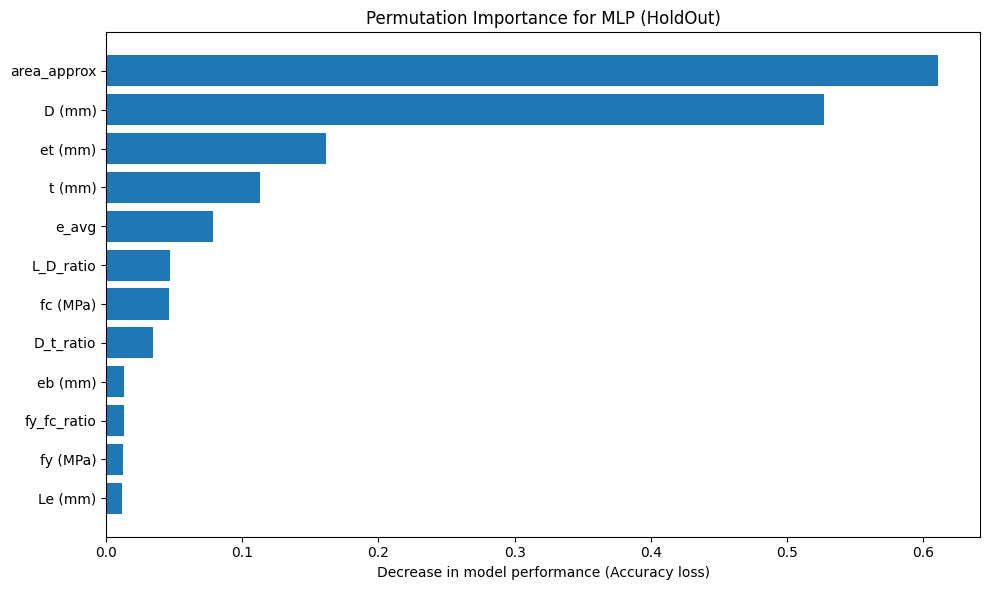

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os

# 1. إعداد المسارات
SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'MLP_HoldOut.pkl')

# 2. تحميل الموديل (الـ Pipeline المحفوظة)
model = joblib.load(model_path)

# 3. حساب الأهمية
# نستخدم X_test التي لم يراها الموديل من قبل لضمان الدقة
# ملاحظة: الموديل هو Pipeline، لذا هو سيقوم بعمل Scaling داخلياً
perm_importance = permutation_importance(model, X_test, y_test,
                                         n_repeats=10, random_state=42, n_jobs=-1)

# 4. التجهيز للرسم
sorted_idx = perm_importance.importances_mean.argsort()
feature_names = X.columns # تأكدي أن X معرفة

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title("Permutation Importance for MLP (HoldOut)")
plt.xlabel("Decrease in model performance (Accuracy loss)")
plt.tight_layout()
plt.show()

### **SHAP Analysis**

جاري حساب قيم SHAP... (قد يستغرق بعض الوقت)


  0%|          | 0/50 [00:00<?, ?it/s]

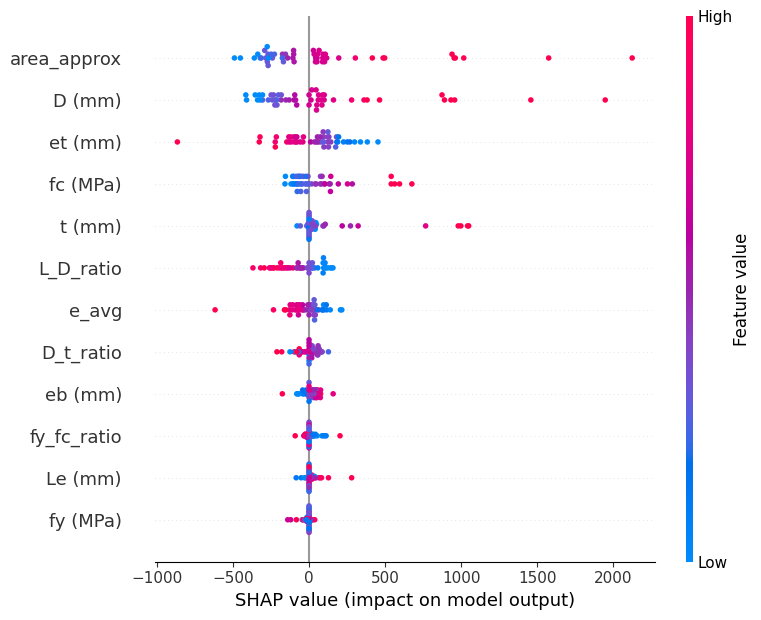

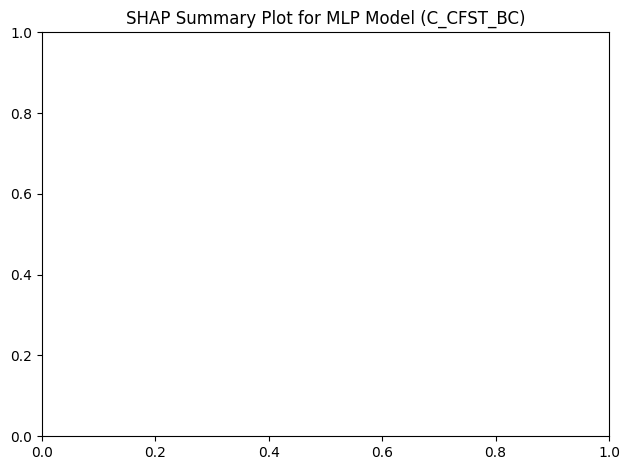

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# 1. إعداد المسارات (تأكدي أن SHEET هو نفس الاسم الذي حفظتِ فيه الموديل)
SHEET = 'C_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'MLP_HoldOut.pkl')

# 2. تحميل الموديل
model = joblib.load(model_path)

# 3. تجهيز الـ Background data
# ملاحظة: نستخدم X_train الأصلية (قبل الـ Scaler) لأن الـ Pipeline ستقوم بالمعالجة داخلياً
background_data = shap.sample(X_train, 50)

# 4. تعريف دالة الـ Wrapper (هذا هو الحل لمشكلة الـ Pipeline)
# هذه الدالة تخفي تفاصيل الـ Pipeline عن SHAP وتسمح له بالتنبؤ فقط
predict_fn = lambda x: model.predict(x)

# 5. تعريف الـ Explainer
explainer = shap.KernelExplainer(predict_fn, background_data)

# 6. حساب القيم (نأخذ عينة من 50 نقطة للاختبار لضمان السرعة)
print("جاري حساب قيم SHAP... (قد يستغرق بعض الوقت)")
shap_values = explainer.shap_values(X_test.iloc[:50], nsamples=100)

# 7. الرسم البياني
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:50], feature_names=X.columns)
plt.title(f"SHAP Summary Plot for MLP Model ({SHEET})")
plt.tight_layout()
plt.show()

"Unlike tree-based ensemble models (e.g., XGBoost) which provide intrinsic feature importance based on decision nodes and information gain, the Multi-Layer Perceptron (MLP) is a non-linear neural network. Due to its complex architecture—comprising multiple layers, weighted connections, and activation functions—it does not offer a direct or inherent way to rank input features. Consequently, the MLP is often classified as a 'black-box' model. To address this and ensure model transparency, post-hoc interpretability techniques, specifically Permutation Importance and SHAP (SHapley Additive exPlanations), were utilized to evaluate the relative contribution of each feature to the model's predictive output."

##  **Sheet 3) CFST_R**


*   XGBoost
*   Stacking



### **Setup**

In [ ]:

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

Dataset: R_CFST
Samples: 979  Features: 11


### **Model 1: XGBoost + Nested CV + Optuna**


In [ ]:

def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':     trial.suggest_int(
                                            'n_estimators', 100, 1200),
                    'learning_rate':    trial.suggest_float(
                                            'learning_rate', 0.005, 0.3,
                                            log=True),
                    'max_depth':        trial.suggest_int(
                                            'max_depth', 3, 12),
                    'subsample':        trial.suggest_float(
                                            'subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float(
                                            'colsample_bytree', 0.5, 1.0),
                    'reg_alpha':        trial.suggest_float(
                                            'reg_alpha', 1e-8, 10.0,
                                            log=True),
                    'reg_lambda':       trial.suggest_float(
                                            'reg_lambda', 1e-8, 10.0,
                                            log=True),
                    'min_child_weight': trial.suggest_int(
                                            'min_child_weight', 1, 10),
                    'gamma':            trial.suggest_float(
                                            'gamma', 1e-8, 1.0,
                                            log=True),
                    'random_state': RANDOM_STATE, 'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Model 2: Stacking (RF + Tuned XGBoost) + Nested CV**


In [ ]:



def run_stacking_nested_cv(X, y, xgb_best_params,
                            label='Stacking'):
    """
    Stacking: RF + Tuned XGBoost → Ridge meta-learner
    بنستخدم أفضل params من Model 1 للـ XGBoost
    """
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # RF params بنعمل tuning بسيط عليها
        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int(
                                        'n_estimators', 100, 500),
                    'max_depth':    trial.suggest_int(
                                        'max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int(
                                             'min_samples_split', 2, 10),
                    'max_features': trial.suggest_float(
                                        'max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })

        # بناء الـ Stacking
        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        stack = StackingRegressor(
            estimators      = estimators,
            final_estimator = Ridge(alpha=1.0),
            cv              = 3,
            n_jobs          = -1,
        )
        stack.fit(X_tr, y_tr)
        y_pred = stack.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':     label,
        'R2_Mean':   round(np.mean(outer_r2),   4),
        'R2_Std':    round(np.std(outer_r2),    4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std':  round(np.std(outer_rmse),  2),
        'MAE':       round(np.mean(outer_mae),  2),
        'MAPE':      round(np.mean(outer_mape), 2),
    }


### **Execution**


In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

# 1. XGBoost
xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

# 2. Stacking بأفضل params من XGBoost
stack_result = run_stacking_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Stacking (RF + XGB)'
)



#######################################################
# SHEET: R_CFST
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9717  RMSE=336.5  depth=8
  Fold 2: R²=0.9633  RMSE=290.8  depth=6
  Fold 3: R²=0.9586  RMSE=439.5  depth=6
  Fold 4: R²=0.9815  RMSE=273.6  depth=8
  Fold 5: R²=0.9845  RMSE=241.8  depth=4

  ✓ XGBoost:
    R²   = 0.9719 ± 0.0100
    RMSE = 316.44 ± 68.71
    MAE  = 159.08
    MAPE = 8.98%

Stacking (RF + XGB) — Nested CV
  Fold 1: R²=0.9470  RMSE=460.4
  Fold 2: R²=0.9583  RMSE=310.0
  Fold 3: R²=0.9744  RMSE=345.4
  Fold 4: R²=0.9816  RMSE=272.8
  Fold 5: R²=0.9719  RMSE=326.1

  ✓ Stacking (RF + XGB):
    R²   = 0.9666 ± 0.0124
    RMSE = 342.94 ± 63.37
    MAE  = 200.36
    MAPE = 12.48%


### **RESULTS**


In [ ]:


print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, stack_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          stack_result['R2_Mean'] else stack_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")




FINAL COMPARISON — R_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9719 ± 0.0100     316.4    159.1    8.98%
Stacking (RF + XGB)    0.9666 ± 0.0124     342.9    200.4   12.48%

✓ Winner for R_CFST: XGBoost (R²=0.9719)


### **Save**


In [ ]:

import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف (إذا لم يكن مربوطاً بالفعل)
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler (ضروري جداً لأي تنبؤ مستقبلي)
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديلات النهائية على كامل البيانات (Full Data)
# ملاحظة: الموديلات في الـ Nested CV تدربت على أجزاء فقط،
# لذا يجب تدريب موديل نهائي على X و y بالكامل باستخدام أفضل Params

# أ. XGBoost النهائي
xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"✓ XGBoost final model saved.")

# ب. Stacking النهائي
# سنعيد بناءه بنفس الـ estimators التي استخدمناها في الـ Nested CV
rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE} # يفضل استخدام أفضل params لو قمتِ بتخزينها
stack_final = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    final_estimator=Ridge(),
    cv=3, n_jobs=-1
)
stack_final.fit(X, y)
joblib.dump(stack_final, os.path.join(BASE_DIR, 'Stacking_NestedCV.pkl'))
print(f"✓ Stacking final model saved.")

# 5. حفظ النتائج (Metrics) في ملف JSON للرجوع إليها لاحقاً
all_results = {
    "XGBoost": xgb_result,
    "Stacking": stack_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

بدء عملية الحفظ في: /content/drive/MyDrive/Master/Final/R_CFST
✓ Scaler saved: /content/drive/MyDrive/Master/Final/R_CFST/scaler.pkl
✓ XGBoost final model saved.
✓ Stacking final model saved.

✅ تم حفظ جميع الملفات بنجاح في الدرايف!


### **Train/Test split 70/30**

In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

# 1. الإعدادات الأساسية
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
# تأكدي أن processed_data معرفة مسبقاً (بنفس الطريقة التي استخدمناها في الشيت الأول)
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaler (XGBoost لا يتأثر كثيراً بالـ Scaling، ولكن يفضل دائماً توحيد المقاييس)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# حفظ الـ Scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل (XGBoost)
# نستخدم بارامترات متوازنة، ويمكنك تعديلها بناءً على ما وجدته في الـ Nested CV
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("جاري التدريب...")
model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n--- نتائج الأداء على مجموعة الاختبار ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

# 7. الحفظ النهائي
joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي في: {BASE_DIR}")

✓ تم تقسيم البيانات: 685 للتدريب، 294 للاختبار.
✓ تم حفظ الـ Scaler.
جاري التدريب...
✓ تم التدريب بنجاح.

--- نتائج الأداء على مجموعة الاختبار ---
R² Score : 0.9623
RMSE     : 366.08
MAE      : 173.79
MAPE     : 8.72%

✅ تم حفظ الموديل النهائي في: /content/drive/MyDrive/Master/Final/R_CFST


### **Feature Importance**

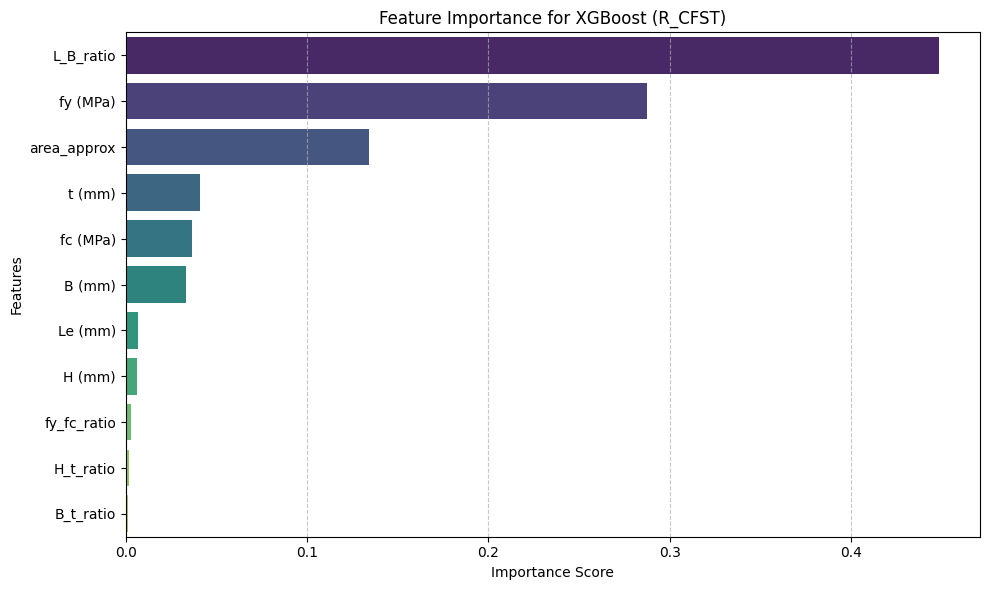

        Feature  Importance
8     L_B_ratio    0.448723
4      fy (MPa)    0.287364
9   area_approx    0.133962
2        t (mm)    0.041150
5      fc (MPa)    0.036719
0        B (mm)    0.033024
3       Le (mm)    0.006955
1        H (mm)    0.006393
10  fy_fc_ratio    0.002839
7     H_t_ratio    0.001826
6     B_t_ratio    0.001046


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد المسارات
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')

# 2. تحميل الموديل والـ Scaler
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# 3. الحصول على أسماء الميزات
# نستخدم feature_names_in_ إذا كانت موجودة، أو نستخدم أعمدة الـ X (تأكدي من تعريفها X)
feature_names = X.columns

# 4. تجهيز البيانات للرسم
importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# 5. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost ({SHEET})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# طباعة الترتيب
print(df_imp)

### **SHAP Analysis**

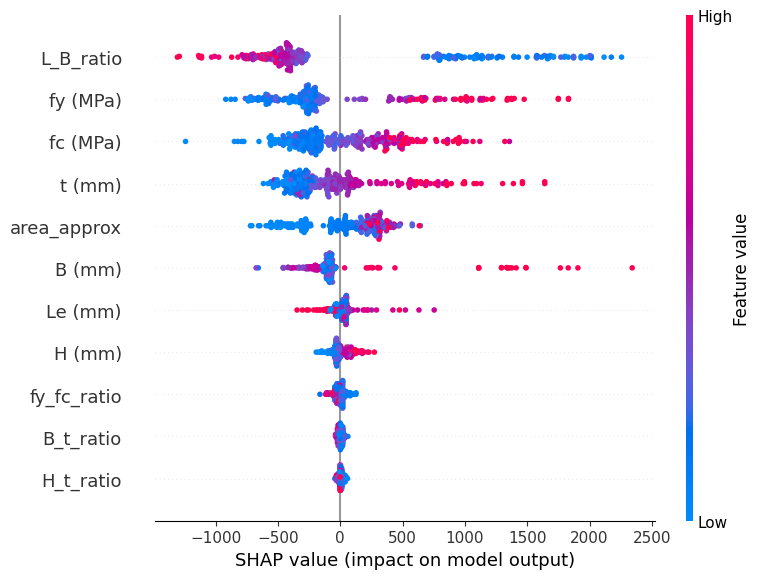

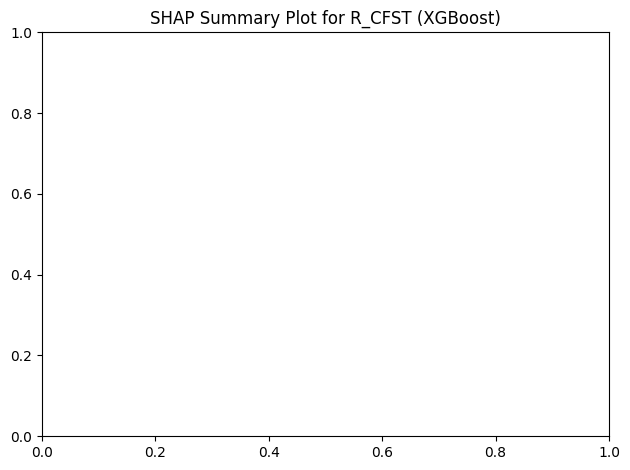

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt

# 1. إعداد المسارات وتحميل الموديل
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)

# 2. تجهيز الـ Explainer (لـ XGBoost نستخدم TreeExplainer)
# نمرر الموديل مباشرة دون الحاجة لـ Wrapper
explainer = shap.TreeExplainer(model)

# 3. حساب قيم SHAP (على بيانات الـ Test)
# نستخدم X_test_scaled (تأكدي أن X_test_scaled معرفة من كود الـ Split السابق)
shap_values = explainer.shap_values(X_test_scaled)

# 4. الرسم البياني (Summary Plot)
plt.figure(figsize=(10, 6))
# نمرر feature_names لتظهر الأسماء بدلاً من أرقام الأعمدة
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.title(f"SHAP Summary Plot for {SHEET} (XGBoost)")
plt.tight_layout()
plt.show()

##  **Sheet 3) CFST_R**


*   Gradient Boosting
*   HistGradientBoosting



In [ ]:
## **Sheet 3) R_CFST — Gradient Boosting + HistGradientBoosting**

# !pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

### **Model 1: Gradient Boosting + Nested CV + Optuna**

def run_gb_nested_cv(X, y, label='Gradient Boosting'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':     trial.suggest_int('n_estimators', 100, 1200),
                    'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'max_depth':        trial.suggest_int('max_depth', 3, 12),
                    'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
                    'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'random_state': RANDOM_STATE
                }
                m = GradientBoostingRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({'random_state': RANDOM_STATE})
        model = GradientBoostingRegressor(**best_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }


### **Model 2: HistGradientBoosting + Nested CV + Optuna**

def run_hgb_nested_cv(X, y, label='HistGradientBoosting'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'max_iter':         trial.suggest_int('max_iter', 100, 1200),
                    'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'max_depth':        trial.suggest_int('max_depth', 3, 12),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
                    'max_leaf_nodes':   trial.suggest_int('max_leaf_nodes', 10, 100),
                    'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
                    'random_state': RANDOM_STATE
                }
                m = HistGradientBoostingRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({'random_state': RANDOM_STATE})
        model = HistGradientBoostingRegressor(**best_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Execution**

print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

# 1. Gradient Boosting
gb_result = run_gb_nested_cv(X, y, label='Gradient Boosting')

# 2. HistGradientBoosting
hgb_result = run_hgb_nested_cv(X, y, label='HistGradientBoosting')

### **RESULTS**

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [gb_result, hgb_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (gb_result if gb_result['R2_Mean'] >= hgb_result['R2_Mean'] else hgb_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} (R²={winner['R2_Mean']:.4f})")



### **Save**

import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_GB_HGB'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديلات النهائية على كامل البيانات

# أ. Gradient Boosting النهائي
gb_final = GradientBoostingRegressor(**gb_result['best_params'])
gb_final.fit(X, y)
joblib.dump(gb_final, os.path.join(BASE_DIR, 'GradientBoosting_NestedCV.pkl'))
print(f"✓ Gradient Boosting final model saved.")

# ب. HistGradientBoosting النهائي
hgb_final = HistGradientBoostingRegressor(**hgb_result['best_params'])
hgb_final.fit(X, y)
joblib.dump(hgb_final, os.path.join(BASE_DIR, 'HistGradientBoosting_NestedCV.pkl'))
print(f"✓ HistGradientBoosting final model saved.")


Dataset: R_CFST
Samples: 979  Features: 11

#######################################################
# SHEET: R_CFST
#######################################################

Gradient Boosting — Nested CV
  Fold 1: R²=0.9692  RMSE=350.8  depth=5
  Fold 2: R²=0.9638  RMSE=288.7  depth=5
  Fold 3: R²=0.9574  RMSE=445.8  depth=9
  Fold 4: R²=0.9867  RMSE=231.4  depth=7
  Fold 5: R²=0.9821  RMSE=260.0  depth=11

  ✓ Gradient Boosting:
    R²   = 0.9719 ± 0.0110
    RMSE = 315.33 ± 76.30
    MAE  = 152.16
    MAPE = 8.28%

HistGradientBoosting — Nested CV
  Fold 1: R²=0.9662  RMSE=367.8  depth=4
  Fold 2: R²=0.9619  RMSE=296.5  depth=3
  Fold 3: R²=0.9668  RMSE=393.5  depth=8
  Fold 4: R²=0.9795  RMSE=287.8  depth=8
  Fold 5: R²=0.9859  RMSE=230.8  depth=3

  ✓ HistGradientBoosting:
    R²   = 0.9720 ± 0.0091
    RMSE = 315.29 ± 58.54
    MAE  = 159.76
    MAPE = 8.87%

FINAL COMPARISON — R_CFST
Model                            R²               RMSE      MAE   MAPE%
--------------------------


✅ تم حفظ جميع الملفات بنجاح في الدرايف!
✓ تم تقسيم البيانات: 685 للتدريب، 294 للاختبار.
✓ تم حفظ الـ Scaler.
جاري التدريب...
✓ تم التدريب بنجاح.

--- نتائج الأداء على مجموعة الاختبار ---
R² Score : 0.9614
RMSE     : 370.16
MAE      : 187.56
MAPE     : 9.47%

✅ تم حفظ الموديل النهائي في: /content/drive/MyDrive/Master/Final/R_CFST_GB_HGB


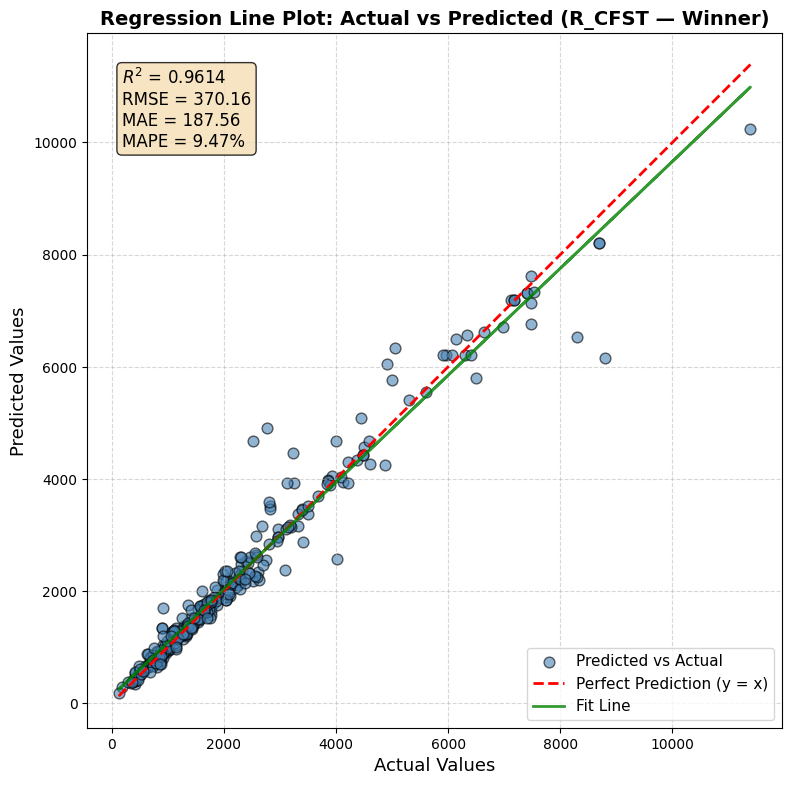

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_GB_HGB/regression_line_plot.png


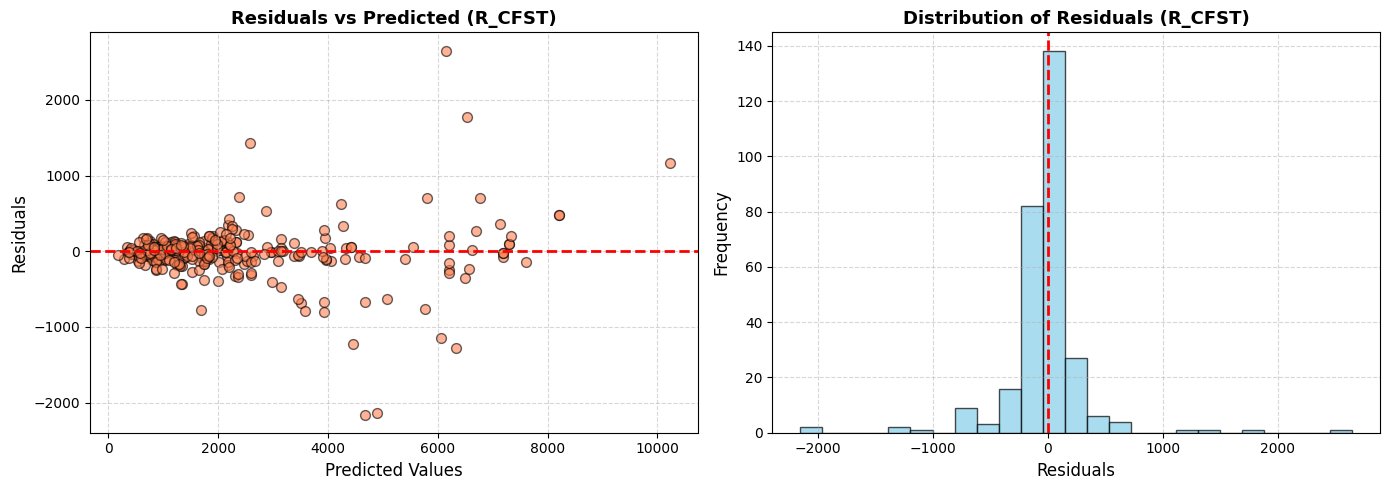

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_GB_HGB/residuals_plot.png


In [ ]:

# 5. حفظ النتائج في JSON
all_results = {
    "Gradient Boosting": gb_result,
    "HistGradientBoosting": hgb_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")



### **Train/Test split 70/30 (للـ Winner)**

import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor

# 1. الإعدادات الأساسية
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_GB_HGB'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# 3. التقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل الفائز (غيّري حسب النتيجة)


# لو الفائز HistGradientBoosting استبدلي بالسطرين دول:
winner_model = HistGradientBoostingRegressor(
  max_iter=500,
  learning_rate=0.05,
  max_depth=6,
    random_state=42)

print("جاري التدريب...")
winner_model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = winner_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n--- نتائج الأداء على مجموعة الاختبار ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

# 7. الحفظ النهائي
joblib.dump(winner_model, os.path.join(BASE_DIR, 'Winner_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي في: {BASE_DIR}")

### **Regression Line Plot**

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue', label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8, label='Fit Line')

textstr = '\n'.join((
    f'$R^2$ = {r2:.4f}',
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'MAPE = {mape:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

ax.set_xlabel('Actual Values', fontsize=13)
ax.set_ylabel('Predicted Values', fontsize=13)
ax.set_title(f'Regression Line Plot: Actual vs Predicted ({SHEET} — Winner)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'regression_line_plot.png')}")

### **Residuals Plot**

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title(f'Residuals vs Predicted ({SHEET})', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Distribution of Residuals ({SHEET})', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'residuals_plot.png')}")

##  **Sheet 3) CFST_R**


*   ExtraTree Regressor



In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.6 MB/s eta 0:00:00


Dataset: R_CFST
Samples: 979  Features: 11

#######################################################
# SHEET: R_CFST
#######################################################

ExtraTrees Regressor — Nested CV
  Fold 1: R²=0.9643  RMSE=378.1  n_est=142  depth=27
  Fold 2: R²=0.9642  RMSE=287.4  n_est=350  depth=25
  Fold 3: R²=0.9432  RMSE=514.8  n_est=575  depth=25
  Fold 4: R²=0.9782  RMSE=297.0  n_est=228  depth=14
  Fold 5: R²=0.9775  RMSE=291.6  n_est=355  depth=26

  ✓ ExtraTrees Regressor:
    R²   = 0.9655 ± 0.0127
    RMSE = 353.77 ± 87.22
    MAE  = 176.37
    MAPE = 9.73%

FINAL RESULTS — R_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
ExtraTrees Regressor   0.9655 ± 0.0127     353.8    176.4    9.73%

✓ Best Params: {'n_estimators': 228, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False, 'random_state': 42, 'n_jobs': -1}
Drive alread

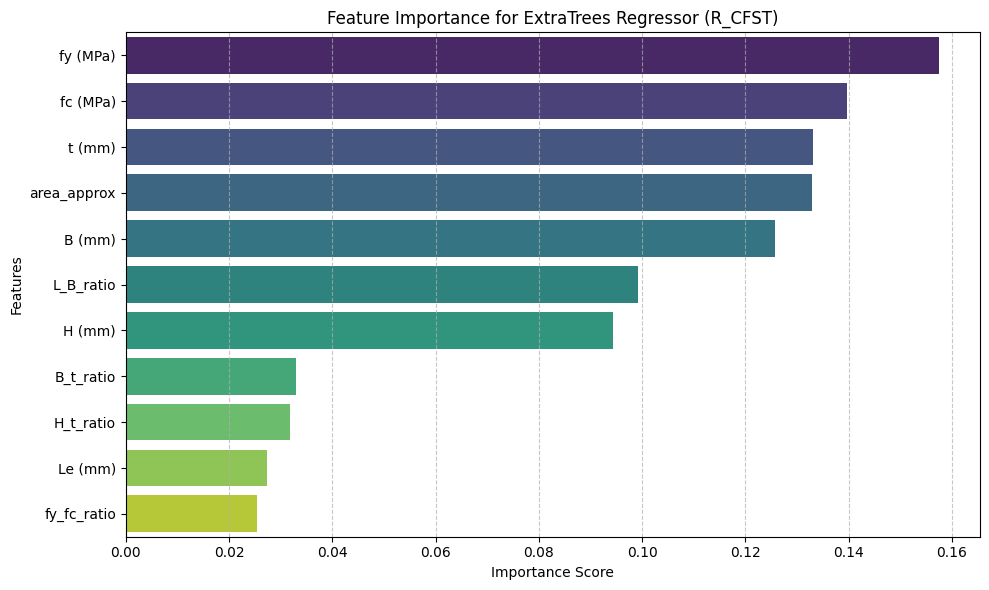

        Feature  Importance
4      fy (MPa)    0.157580
5      fc (MPa)    0.139610
2        t (mm)    0.133120
9   area_approx    0.132847
0        B (mm)    0.125816
8     L_B_ratio    0.099122
1        H (mm)    0.094342
6     B_t_ratio    0.032951
7     H_t_ratio    0.031872
3       Le (mm)    0.027328
10  fy_fc_ratio    0.025411


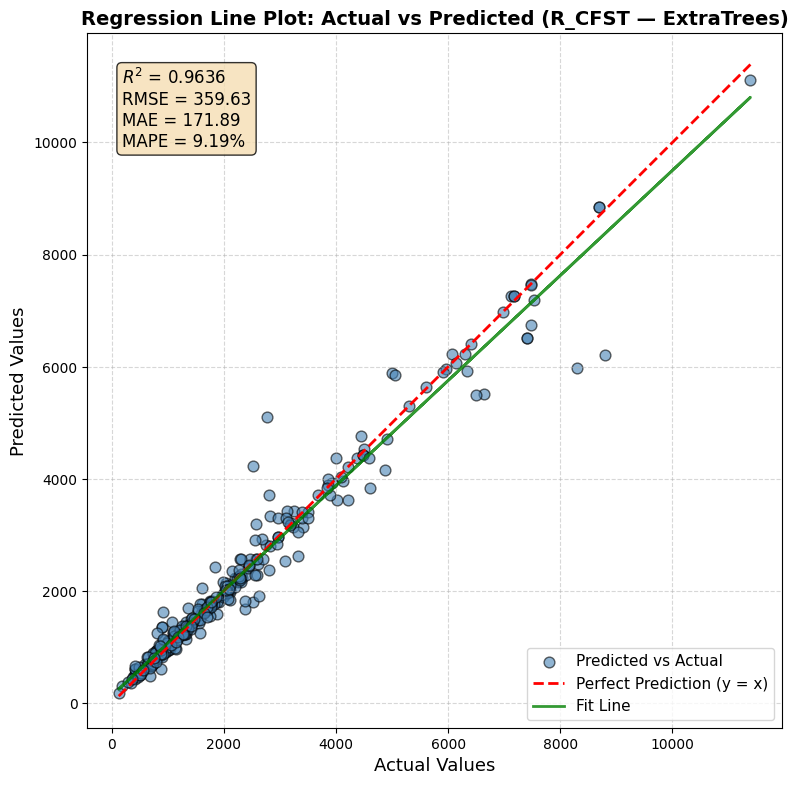

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_ExtraTrees/regression_line_plot.png


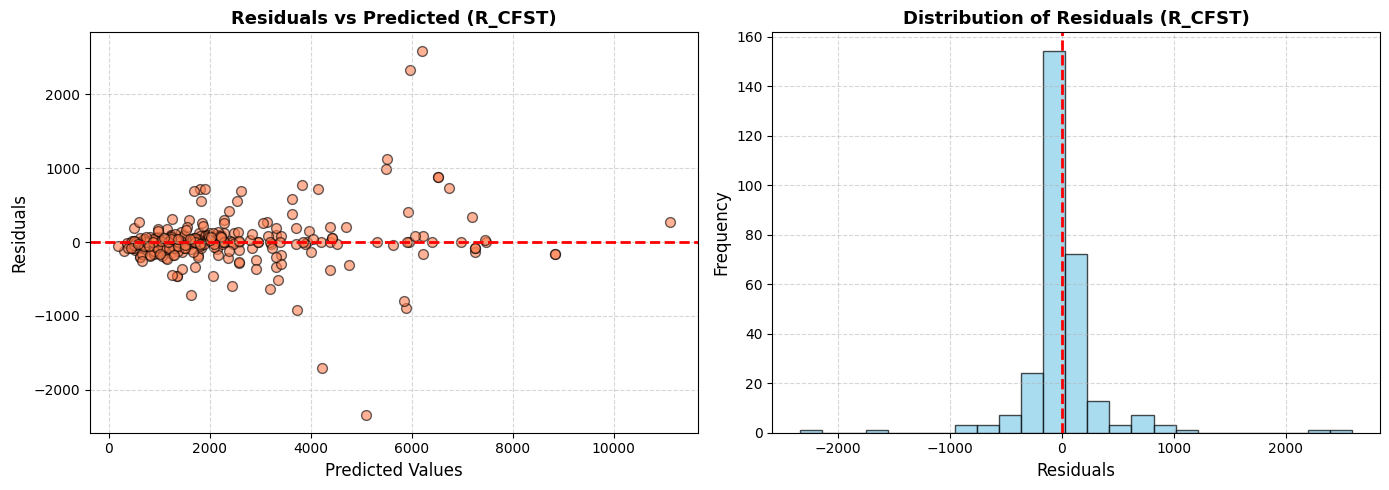

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_ExtraTrees/residuals_plot.png


In [ ]:
## **Sheet 3) R_CFST — ExtraTrees Regressor + Nested CV + Optuna**

#

import optuna
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

### **Model: ExtraTrees Regressor + Nested CV + Optuna**

def run_extratrees_nested_cv(X, y, label='ExtraTrees Regressor'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':     trial.suggest_int('n_estimators', 100, 1200),
                    'max_depth':        trial.suggest_int('max_depth', 3, 30),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
                    'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'bootstrap':        trial.suggest_categorical('bootstrap', [True, False]),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                m = ExtraTreesRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})
        model = ExtraTreesRegressor(**best_params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"n_est={best_params['n_estimators']}  depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Execution**

print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

# ExtraTrees Regressor
et_result = run_extratrees_nested_cv(X, y, label='ExtraTrees Regressor')

### **RESULTS**

print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

res = et_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")

print("="*60)
print(f"\n✓ Best Params: {et_result['best_params']}")



### **Save**

import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_ExtraTrees'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديل النهائي على كامل البيانات
et_final = ExtraTreesRegressor(**et_result['best_params'])
et_final.fit(X, y)
joblib.dump(et_final, os.path.join(BASE_DIR, 'ExtraTrees_NestedCV.pkl'))
print(f"✓ ExtraTrees final model saved.")

# 5. حفظ النتائج في JSON
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(et_result, f, indent=4)
print(f"✓ Results saved.")

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")



### **Train/Test split 70/30 (HoldOut Validation)**

import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import ExtraTreesRegressor

# 1. الإعدادات الأساسية
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_ExtraTrees'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# 3. التقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل (بأفضل params من Nested CV أو افتراضية)
et_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

print("جاري التدريب...")
et_model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = et_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n--- نتائج الأداء على مجموعة الاختبار ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

# 7. الحفظ النهائي
joblib.dump(et_model, os.path.join(BASE_DIR, 'ExtraTrees_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي في: {BASE_DIR}")

### **Feature Importance**

import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد المسارات
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_ExtraTrees'
model_path = os.path.join(BASE_DIR, 'ExtraTrees_HoldOut.pkl')

# 2. تحميل الموديل
loaded_model = joblib.load(model_path)

# 3. الحصول على أسماء الميزات
feature_names = X.columns

# 4. تجهيز البيانات للرسم
importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# 5. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for ExtraTrees Regressor ({SHEET})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

# طباعة الترتيب
print(df_imp)

### **Regression Line Plot**

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue', label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8, label='Fit Line')

textstr = '\n'.join((
    f'$R^2$ = {r2:.4f}',
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'MAPE = {mape:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

ax.set_xlabel('Actual Values', fontsize=13)
ax.set_ylabel('Predicted Values', fontsize=13)
ax.set_title(f'Regression Line Plot: Actual vs Predicted ({SHEET} — ExtraTrees)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'regression_line_plot.png')}")

### **Residuals Plot**

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title(f'Residuals vs Predicted ({SHEET})', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Distribution of Residuals ({SHEET})', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'residuals_plot.png')}")

## **Sheet 3) R_CFST — MLP Regressor + Nested CV + Optuna**


Dataset: R_CFST
Samples: 979  Features: 11

#######################################################
# ⭐SHEET: R_CFST
#######################################################

MLP Regressor — Nested CV
  Fold 1: R²=0.9179  RMSE=525.4  layers=2  units=[136, 492]
  Fold 2: R²=0.9684  RMSE=357.4  layers=1  units=[290]
  Fold 3: R²=0.9741  RMSE=317.2  layers=2  units=[498, 494]

  ✓ MLP Regressor:
    R²   = 0.9535 ± 0.0253
    RMSE = 400.00 ± 90.18
    MAE  = 199.23
    MAPE = 11.28%

FINAL RESULTS — R_CFST
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
MLP Regressor          0.9535 ± 0.0253     400.0    199.2   11.28%

✓ Best Params:
  n_layers: 2
  n_units_l0: 498
  n_units_l1: 494
  activation: relu
  solver: lbfgs
  alpha: 0.001388
  learning_rate_init: 0.000612
  batch_size: 64
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=Tru

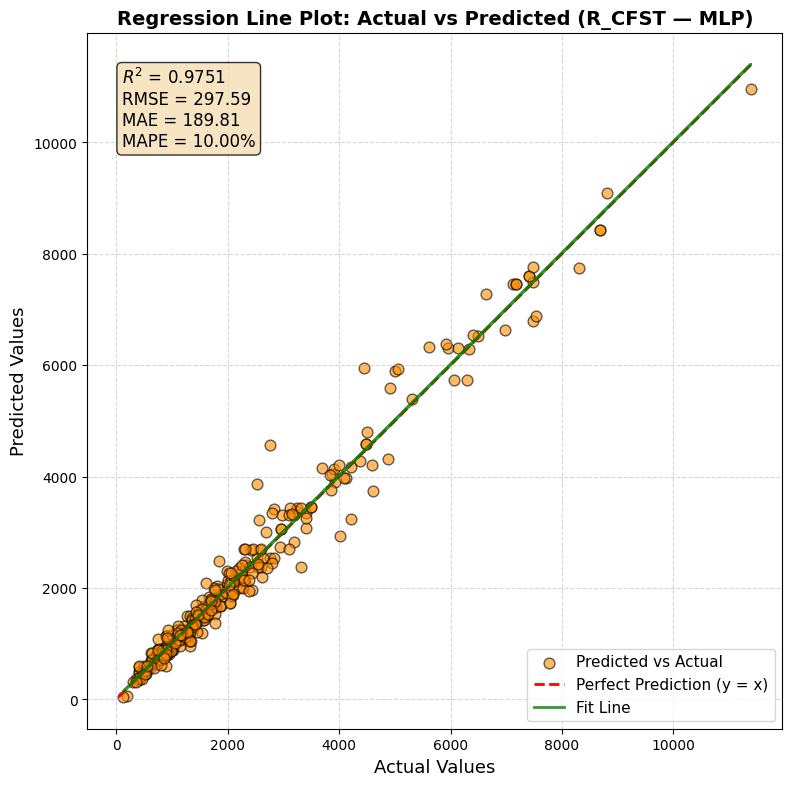

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_MLP/regression_line_plot.png


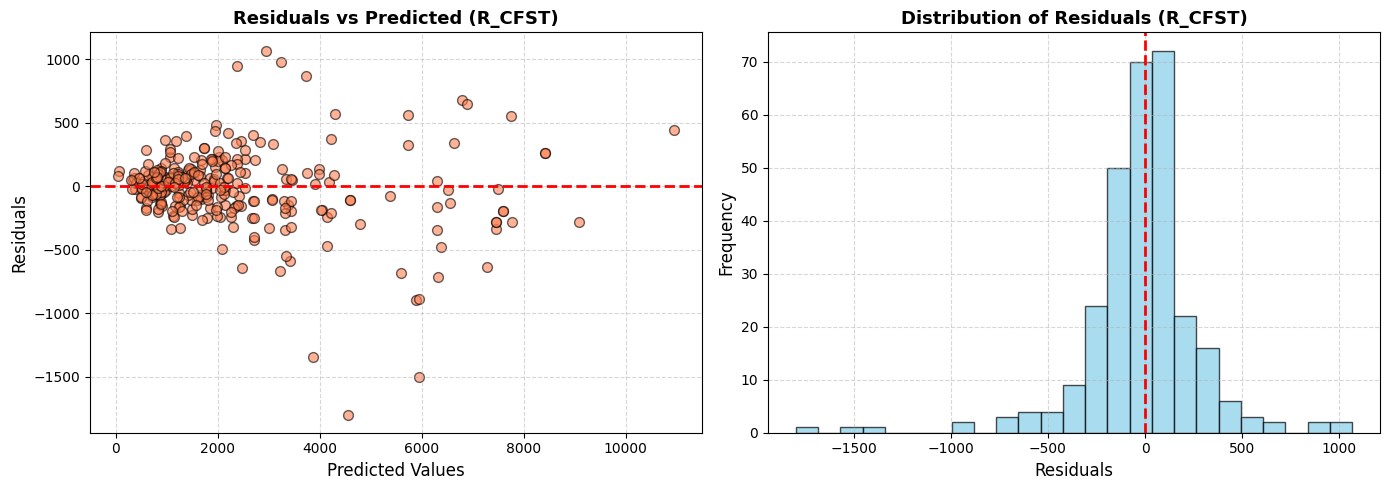

✓ Figure saved to: /content/drive/MyDrive/Master/Final/R_CFST_MLP/residuals_plot.png


In [ ]:
## **Sheet 3) R_CFST — MLP Regressor + Nested CV + Optuna**

# !pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST'
RANDOM_STATE = 42
N_SPLITS_OUTER = 3
N_SPLITS_INNER = 2
N_TRIALS       = 20

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

### **Model: MLP Regressor + Nested CV + Optuna**

def run_mlp_nested_cv(X, y, label='MLP Regressor'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # Scaling داخل كل Fold (مهم جداً للـ MLP)
        scaler_inner = StandardScaler()
        X_in_tr_scaled = scaler_inner.fit_transform(X_tr)
        X_in_te_scaled = scaler_inner.transform(X_te)

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_in_tr_scaled):
            X_in_tr  = X_in_tr_scaled[in_tr_idx]
            X_in_val = X_in_tr_scaled[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                # تحديد عدد الطبقات وعدد النيورونز في كل طبقة
                n_layers = trial.suggest_int('n_layers', 1, 3)
                hidden_layers = tuple(
                    trial.suggest_int(f'n_units_l{i}', 32, 512, log=True)
                    for i in range(n_layers)
                )

                p = {
                    'hidden_layer_sizes': hidden_layers,
                    'activation':         trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
                    'solver':             trial.suggest_categorical('solver', ['adam', 'lbfgs']),
                    'alpha':              trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
                    'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
                    'batch_size':         trial.suggest_categorical('batch_size', [16, 32, 64, 128, 'auto']),
                    'max_iter':           2000,
                    'early_stopping':     True,
                    'validation_fraction': 0.1,
                    'n_iter_no_change':   20,
                    'random_state':       RANDOM_STATE
                }

                # lbfgs مش بيدعم early_stopping وbatch_size
                if p['solver'] == 'lbfgs':
                    p['early_stopping'] = False
                    p['batch_size'] = 'auto'

                m = MLPRegressor(**p)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        # تدريب الموديل النهائي على Fold الخارجي
        best_hidden = tuple(
            best_params[f'n_units_l{i}']
            for i in range(best_params['n_layers'])
        )

        final_params = {
            'hidden_layer_sizes':  best_hidden,
            'activation':          best_params['activation'],
            'solver':              best_params['solver'],
            'alpha':               best_params['alpha'],
            'learning_rate_init':  best_params['learning_rate_init'],
            'batch_size':          best_params['batch_size'],
            'max_iter':            2000,
            'early_stopping':      True,
            'validation_fraction': 0.1,
            'n_iter_no_change':    20,
            'random_state':        RANDOM_STATE
        }

        if final_params['solver'] == 'lbfgs':
            final_params['early_stopping'] = False
            final_params['batch_size'] = 'auto'

        model = MLPRegressor(**final_params)
        model.fit(X_in_tr_scaled, y_tr)
        y_pred = model.predict(X_in_te_scaled)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"layers={best_params['n_layers']}  "
              f"units={[best_params[f'n_units_l{i}'] for i in range(best_params['n_layers'])]}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }

### **Execution**

print(f"\n{'#'*55}")
print(f"# ⭐SHEET: {SHEET}")
print(f"{'#'*55}")

# MLP Regressor
mlp_result = run_mlp_nested_cv(X, y, label='MLP Regressor')

### **RESULTS**

print(f"\n{'='*60}")
print(f"FINAL RESULTS — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

res = mlp_result
print(f"{res['model']:<22} "
      f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
      f"{res['RMSE_Mean']:>8.1f} "
      f"{res['MAE']:>8.1f} "
      f"{res['MAPE']:>7.2f}%")

print("="*60)

# طباعة أفضل بارامترات
bp = mlp_result['best_params']
print(f"\n✓ Best Params:")
print(f"  n_layers: {bp['n_layers']}")
for i in range(bp['n_layers']):
    print(f"  n_units_l{i}: {bp[f'n_units_l{i}']}")
print(f"  activation: {bp['activation']}")
print(f"  solver: {bp['solver']}")
print(f"  alpha: {bp['alpha']:.6f}")
print(f"  learning_rate_init: {bp['learning_rate_init']:.6f}")
print(f"  batch_size: {bp['batch_size']}")



### **Save**

import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler (الخارجي للـ HoldOut)
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديل النهائي على كامل البيانات
bp = mlp_result['best_params']
best_hidden = tuple(bp[f'n_units_l{i}'] for i in range(bp['n_layers']))

final_params = {
    'hidden_layer_sizes':  best_hidden,
    'activation':          bp['activation'],
    'solver':              bp['solver'],
    'alpha':               bp['alpha'],
    'learning_rate_init':  bp['learning_rate_init'],
    'batch_size':          bp['batch_size'],
    'max_iter':            3000,
    'early_stopping':      True,
    'validation_fraction': 0.1,
    'n_iter_no_change':    50,
    'random_state':        RANDOM_STATE
}

if final_params['solver'] == 'lbfgs':
    final_params['early_stopping'] = False
    final_params['batch_size'] = 'auto'

# Scaling كامل البيانات
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

mlp_final = MLPRegressor(**final_params)
mlp_final.fit(X_scaled_full, y)

joblib.dump(mlp_final, os.path.join(BASE_DIR, 'MLP_NestedCV.pkl'))
joblib.dump(scaler_full, os.path.join(BASE_DIR, 'scaler_full.pkl'))
print(f"✓ MLP final model saved.")

# 5. حفظ النتائج في JSON
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(mlp_result, f, indent=4)
print(f"✓ Results saved.")

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")



### **Train/Test split 70/30 (HoldOut Validation)**

import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor

# 1. الإعدادات الأساسية
SHEET = 'R_CFST'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}_MLP'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# 3. التقسيم
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaling (إجباري للـ MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler_holdout.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل (بأفضل params من Nested CV أو افتراضية)
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

print("جاري التدريب...")
mlp_model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = mlp_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n--- نتائج الأداء على مجموعة الاختبار ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

# 7. الحفظ النهائي
joblib.dump(mlp_model, os.path.join(BASE_DIR, 'MLP_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل النهائي في: {BASE_DIR}")

### **Regression Line Plot**

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='darkorange', label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
ax.plot(y_test, p(y_test), 'g-', lw=2, alpha=0.8, label='Fit Line')

textstr = '\n'.join((
    f'$R^2$ = {r2:.4f}',
    f'RMSE = {rmse:.2f}',
    f'MAE = {mae:.2f}',
    f'MAPE = {mape:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

ax.set_xlabel('Actual Values', fontsize=13)
ax.set_ylabel('Predicted Values', fontsize=13)
ax.set_title(f'Regression Line Plot: Actual vs Predicted ({SHEET} — MLP)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'regression_line_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'regression_line_plot.png')}")

### **Residuals Plot**

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred
ax1.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50, color='coral')
ax1.axhline(y=0, color='r', linestyle='--', lw=2)
ax1.set_xlabel('Predicted Values', fontsize=12)
ax1.set_ylabel('Residuals', fontsize=12)
ax1.set_title(f'Residuals vs Predicted ({SHEET})', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(residuals, bins=25, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Residuals', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Distribution of Residuals ({SHEET})', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'residuals_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {os.path.join(BASE_DIR, 'residuals_plot.png')}")

## **Sheet 4) R_CFST_BC**


*   XGBoost
*    Voting(RF+XGboost)



### **Setup**

In [ ]:

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SHEET        = 'R_CFST_BC'
RANDOM_STATE = 42
N_SPLITS_OUTER = 5
N_SPLITS_INNER = 3
N_TRIALS       = 40

X = scaled_data[SHEET]['X']
y = scaled_data[SHEET]['y']

print(f"Dataset: {SHEET}")
print(f"Samples: {len(y)}  Features: {X.shape[1]}")

Dataset: R_CFST_BC
Samples: 370  Features: 14


### **Model 1: XGBoost + Nested CV + Optuna**


In [ ]:


def run_xgb_nested_cv(X, y, label='XGBoost'):
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []
    all_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_params, best_score = None, -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def objective(trial):
                p = {
                    'n_estimators':     trial.suggest_int(
                                            'n_estimators', 100, 1200),
                    'learning_rate':    trial.suggest_float(
                                            'learning_rate', 0.005, 0.3,
                                            log=True),
                    'max_depth':        trial.suggest_int(
                                            'max_depth', 3, 12),
                    'subsample':        trial.suggest_float(
                                            'subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float(
                                            'colsample_bytree', 0.5, 1.0),
                    'reg_alpha':        trial.suggest_float(
                                            'reg_alpha', 1e-8, 10.0,
                                            log=True),
                    'reg_lambda':       trial.suggest_float(
                                            'reg_lambda', 1e-8, 10.0,
                                            log=True),
                    'min_child_weight': trial.suggest_int(
                                            'min_child_weight', 1, 10),
                    'gamma':            trial.suggest_float(
                                            'gamma', 1e-8, 1.0,
                                            log=True),
                    'random_state': RANDOM_STATE, 'n_jobs': -1
                }
                m = xgb.XGBRegressor(**p, verbosity=0)
                m.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, m.predict(X_in_val))

            study = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study.optimize(objective, n_trials=N_TRIALS,
                           show_progress_bar=False)

            if study.best_value > best_score:
                best_score  = study.best_value
                best_params = study.best_params

        best_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })
        model = xgb.XGBRegressor(**best_params, verbosity=0)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)
        all_best_params.append(best_params.copy())

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}  "
              f"depth={best_params['max_depth']}")

    best_fold_idx = int(np.argmax(outer_r2))

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':       label,
        'R2_Mean':     round(np.mean(outer_r2),   4),
        'R2_Std':      round(np.std(outer_r2),    4),
        'RMSE_Mean':   round(np.mean(outer_rmse), 2),
        'RMSE_Std':    round(np.std(outer_rmse),  2),
        'MAE':         round(np.mean(outer_mae),  2),
        'MAPE':        round(np.mean(outer_mape), 2),
        'best_params': all_best_params[best_fold_idx],
    }



### **Model 2: Voting (RF + Tuned XGBoost) + Nested CV**


In [ ]:

def run_voting_nested_cv(X, y, xgb_best_params,
                            label='Voting'):
    """
    Voting: RF + Tuned XGBoost (Average)
    بنستخدم أفضل params من Model 1 للـ XGBoost
    """
    print(f"\n{'='*55}")
    print(f"{label} — Nested CV")
    print(f"{'='*55}")

    outer_cv = KFold(n_splits=N_SPLITS_OUTER,
                     shuffle=True, random_state=RANDOM_STATE)

    outer_r2, outer_rmse, outer_mae, outer_mape = [], [], [], []

    for fold, (tr_idx, te_idx) in enumerate(
            outer_cv.split(X), 1):

        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        # RF params بنعمل tuning بسيط عليها
        inner_cv   = KFold(n_splits=N_SPLITS_INNER,
                           shuffle=True,
                           random_state=RANDOM_STATE)
        best_rf_params = None
        best_score     = -np.inf

        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            X_in_tr  = X_tr.iloc[in_tr_idx]
            X_in_val = X_tr.iloc[in_val_idx]
            y_in_tr  = y_tr.iloc[in_tr_idx]
            y_in_val = y_tr.iloc[in_val_idx]

            def rf_objective(trial):
                p = {
                    'n_estimators': trial.suggest_int(
                                        'n_estimators', 100, 500),
                    'max_depth':    trial.suggest_int(
                                        'max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int(
                                             'min_samples_split', 2, 10),
                    'max_features': trial.suggest_float(
                                        'max_features', 0.3, 1.0),
                    'random_state': RANDOM_STATE,
                    'n_jobs': -1
                }
                rf = RandomForestRegressor(**p)
                rf.fit(X_in_tr, y_in_tr)
                return r2_score(y_in_val, rf.predict(X_in_val))

            study_rf = optuna.create_study(
                direction='maximize',
                sampler=optuna.samplers.TPESampler(
                    seed=RANDOM_STATE)
            )
            study_rf.optimize(rf_objective,
                              n_trials=N_TRIALS // 2,
                              show_progress_bar=False)

            if study_rf.best_value > best_score:
                best_score     = study_rf.best_value
                best_rf_params = study_rf.best_params

        best_rf_params.update({
            'random_state': RANDOM_STATE, 'n_jobs': -1
        })

        # بناء الـ Voting
        estimators = [
            ('rf',  RandomForestRegressor(**best_rf_params)),
            ('xgb', xgb.XGBRegressor(
                **xgb_best_params, verbosity=0)),
        ]
        voting = VotingRegressor(
            estimators = estimators,
            n_jobs     = -1,
        )
        voting.fit(X_tr, y_tr)
        y_pred = voting.predict(X_te)

        r2   = r2_score(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        mae  = mean_absolute_error(y_te, y_pred)
        mape = np.mean(np.abs((y_te - y_pred) / y_te)) * 100

        outer_r2.append(r2)
        outer_rmse.append(rmse)
        outer_mae.append(mae)
        outer_mape.append(mape)

        print(f"  Fold {fold}: R²={r2:.4f}  RMSE={rmse:.1f}")

    print(f"\n  ✓ {label}:")
    print(f"    R²   = {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")
    print(f"    RMSE = {np.mean(outer_rmse):.2f} ± {np.std(outer_rmse):.2f}")
    print(f"    MAE  = {np.mean(outer_mae):.2f}")
    print(f"    MAPE = {np.mean(outer_mape):.2f}%")

    return {
        'model':     label,
        'R2_Mean':   round(np.mean(outer_r2),   4),
        'R2_Std':    round(np.std(outer_r2),    4),
        'RMSE_Mean': round(np.mean(outer_rmse), 2),
        'RMSE_Std':  round(np.std(outer_rmse),  2),
        'MAE':       round(np.mean(outer_mae),  2),
        'MAPE':      round(np.mean(outer_mape), 2),
    }

### **Execution**


In [ ]:
print(f"\n{'#'*55}")
print(f"# SHEET: {SHEET}")
print(f"{'#'*55}")

# 1. XGBoost
xgb_result = run_xgb_nested_cv(X, y, label='XGBoost')

# 2. Voting بأفضل params من XGBoost
voting_result = run_voting_nested_cv(
    X, y,
    xgb_best_params = xgb_result['best_params'],
    label           = 'Voting (RF + XGB)'
)


#######################################################
# SHEET: R_CFST_BC
#######################################################

XGBoost — Nested CV
  Fold 1: R²=0.9775  RMSE=124.1  depth=5
  Fold 2: R²=0.9718  RMSE=209.3  depth=3
  Fold 3: R²=0.9734  RMSE=129.2  depth=7
  Fold 4: R²=0.9909  RMSE=102.8  depth=3
  Fold 5: R²=0.9209  RMSE=288.7  depth=4

  ✓ XGBoost:
    R²   = 0.9669 ± 0.0240
    RMSE = 170.82 ± 69.16
    MAE  = 92.94
    MAPE = 9.76%

Voting (RF + XGB) — Nested CV
  Fold 1: R²=0.9688  RMSE=146.3
  Fold 2: R²=0.9428  RMSE=298.4
  Fold 3: R²=0.9702  RMSE=136.8
  Fold 4: R²=0.9839  RMSE=136.5
  Fold 5: R²=0.8707  RMSE=369.1

  ✓ Voting (RF + XGB):
    R²   = 0.9473 ± 0.0405
    RMSE = 217.43 ± 97.63
    MAE  = 118.95
    MAPE = 11.69%


### **RESULTS**


In [ ]:

print(f"\n{'='*60}")
print(f"FINAL COMPARISON — {SHEET}")
print(f"{'='*60}")
print(f"{'Model':<22} {'R²':^22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>7}")
print("-"*60)

for res in [xgb_result, voting_result]:
    print(f"{res['model']:<22} "
          f"{res['R2_Mean']:.4f} ± {res['R2_Std']:.4f}  "
          f"{res['RMSE_Mean']:>8.1f} "
          f"{res['MAE']:>8.1f} "
          f"{res['MAPE']:>7.2f}%")

print("="*60)

winner = (xgb_result if xgb_result['R2_Mean'] >=
          voting_result['R2_Mean'] else voting_result)
print(f"\n✓ Winner for {SHEET}: {winner['model']} "
      f"(R²={winner['R2_Mean']:.4f})")





FINAL COMPARISON — R_CFST_BC
Model                            R²               RMSE      MAE   MAPE%
------------------------------------------------------------
XGBoost                0.9669 ± 0.0240     170.8     92.9    9.76%
Voting (RF + XGB)      0.9473 ± 0.0405     217.4    119.0   11.69%

✓ Winner for R_CFST_BC: XGBoost (R²=0.9669)


### **Save**


In [ ]:


import joblib
import json
import os
from google.colab import drive

# 1. ربط الدرايف (إذا لم يكن مربوطاً بالفعل)
drive.mount('/content/drive')

# 2. إعداد المجلدات
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

print(f"\n{'='*55}\nبدء عملية الحفظ في: {BASE_DIR}\n{'='*55}")

# 3. حفظ الـ Scaler (ضروري جداً لأي تنبؤ مستقبلي)
scaler_path = os.path.join(BASE_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 4. تدريب الموديلات النهائية على كامل البيانات (Full Data)
# ملاحظة: الموديلات في الـ Nested CV تدربت على أجزاء فقط،
# لذا يجب تدريب موديل نهائي على X و y بالكامل باستخدام أفضل Params

# أ. XGBoost النهائي
xgb_final = xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0)
xgb_final.fit(X, y)
joblib.dump(xgb_final, os.path.join(BASE_DIR, 'XGBoost_NestedCV.pkl'))
print(f"✓ XGBoost final model saved.")

# ب. Voting النهائي
# سنعيد بناءه بنفس الـ estimators التي استخدمناها في الـ Nested CV
rf_best_params = {'n_estimators': 300, 'max_depth': 10, 'random_state': RANDOM_STATE} # يفضل استخدام أفضل params لو قمتِ بتخزينها
voting_final = VotingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(**rf_best_params, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**xgb_result['best_params'], verbosity=0))
    ],
    n_jobs=-1
)
voting_final.fit(X, y)
joblib.dump(voting_final, os.path.join(BASE_DIR, 'Voting_NestedCV.pkl'))
print(f"✓ Voting final model saved.")

# 5. حفظ النتائج (Metrics) في ملف JSON للرجوع إليها لاحقاً
all_results = {
    "XGBoost": xgb_result,
    "Voting": voting_result
}
with open(os.path.join(BASE_DIR, 'results.json'), 'w') as f:
    json.dump(all_results, f, indent=4)

print(f"\n✅ تم حفظ جميع الملفات بنجاح في الدرايف!")
print(f"يمكنك الآن استخدام الموديلات المحفوظة في أي وقت لعمل SHAP أو Feature Importance.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

بدء عملية الحفظ في: /content/drive/MyDrive/Master/Final/R_CFST_BC
✓ Scaler saved: /content/drive/MyDrive/Master/Final/R_CFST_BC/scaler.pkl
✓ XGBoost final model saved.
✓ Voting final model saved.

✅ تم حفظ جميع الملفات بنجاح في الدرايف!
يمكنك الآن استخدام الموديلات المحفوظة في أي وقت لعمل SHAP أو Feature Importance.


### **Train/Test split 70/30**


In [ ]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

# 1. إعداد المسارات
SHEET = 'R_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. تجهيز البيانات
# تأكدي أن X و y معرفين (من نفس المتغيرات التي استخدمتِها في تقييم الـ CV)
X = processed_data[SHEET]['X']
y = processed_data[SHEET]['y']

# 3. التقسيم (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✓ تم تقسيم البيانات: {X_train.shape[0]} للتدريب، {X_test.shape[0]} للاختبار.")

# 4. الـ Scaling
# نستخدم RobustScaler لتعامله الجيد مع الـ Outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# حفظ الـ Scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scaler.pkl'))
print("✓ تم حفظ الـ Scaler.")

# 5. تدريب الموديل (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("جاري التدريب...")
model.fit(X_train_scaled, y_train)
print("✓ تم التدريب بنجاح.")

# 6. التقييم
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n--- نتائج الأداء على مجموعة الاختبار ({SHEET}) ---")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")
print(f"MAPE     : {mape:.2f}%")

# 7. الحفظ النهائي
joblib.dump(model, os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl'))
print(f"\n✅ تم حفظ الموديل في: {BASE_DIR}")

✓ تم تقسيم البيانات: 296 للتدريب، 74 للاختبار.
✓ تم حفظ الـ Scaler.
جاري التدريب...
✓ تم التدريب بنجاح.

--- نتائج الأداء على مجموعة الاختبار (R_CFST_BC) ---
R² Score : 0.9792
RMSE     : 119.30
MAE      : 80.62
MAPE     : 10.51%

✅ تم حفظ الموديل في: /content/drive/MyDrive/Master/Final/R_CFST_BC


### **Feature Importance**

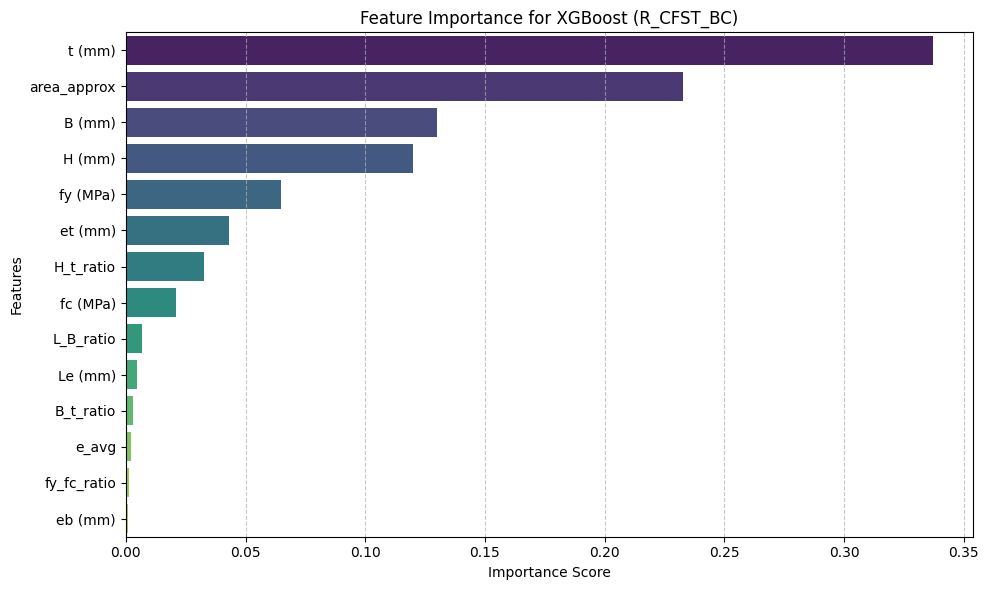

        Feature  Importance
2        t (mm)    0.336878
11  area_approx    0.232665
0        B (mm)    0.129947
1        H (mm)    0.120097
4      fy (MPa)    0.064883
6       et (mm)    0.042954
9     H_t_ratio    0.032792
5      fc (MPa)    0.020905
10    L_B_ratio    0.006707
3       Le (mm)    0.004886
8     B_t_ratio    0.003194
13        e_avg    0.002182
12  fy_fc_ratio    0.001139
7       eb (mm)    0.000770


In [ ]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد المسارات (تأكدي من صحة المسار)
SHEET = 'R_CFST_BC'
BASE_DIR = f'/content/drive/MyDrive/Master/Final/{SHEET}'
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')

# 2. تحميل الموديل
loaded_model = joblib.load(model_path)

# 3. الحصول على أسماء الميزات (تأكدي أن متغير X هو الداتا فريم الأصلي قبل التقسيم)
feature_names = X.columns

# 4. تجهيز البيانات للرسم
importances = loaded_model.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# 5. الرسم البياني
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title(f'Feature Importance for XGBoost ({SHEET})')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# طباعة الترتيب
print(df_imp)

### **SHAP Analysis**

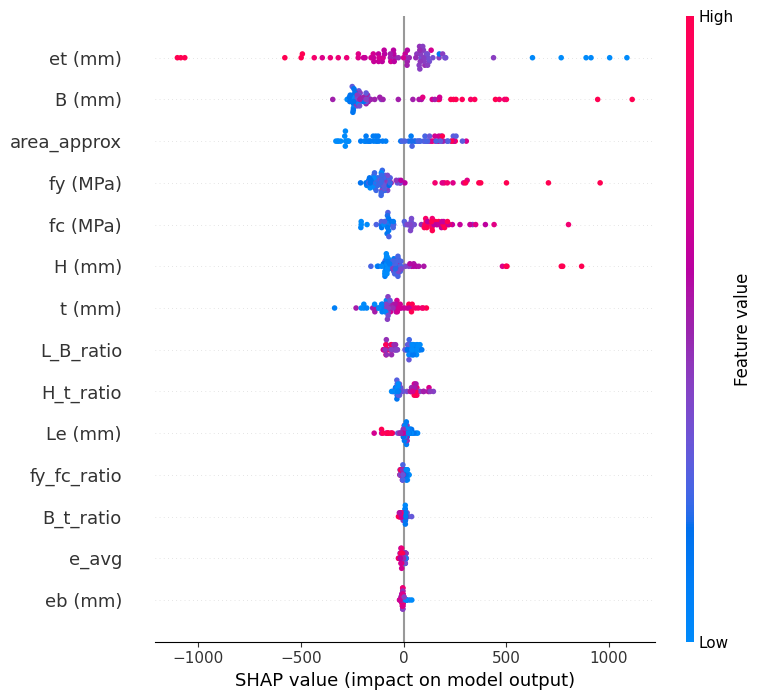

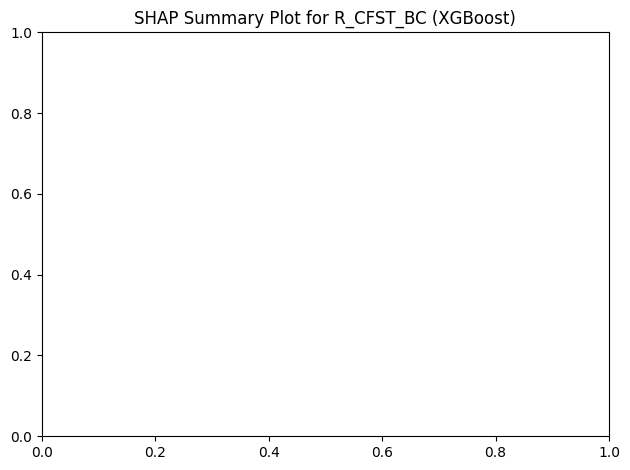

In [ ]:
import shap
import joblib
import os
import matplotlib.pyplot as plt

# 1. تحميل الموديل
model_path = os.path.join(BASE_DIR, 'XGBoost_HoldOut.pkl')
model = joblib.load(model_path)

# 2. تعريف الـ TreeExplainer (الأسرع والأدق لـ XGBoost)
explainer = shap.TreeExplainer(model)

# 3. حساب قيم SHAP (على بيانات الاختبار Scaled)
# تأكدي أن X_test_scaled معرفة من خطوة الـ Hold-out السابقة
shap_values = explainer.shap_values(X_test_scaled)

# 4. الرسم البياني (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.title(f"SHAP Summary Plot for {SHEET} (XGBoost)")
plt.tight_layout()
plt.show()

# **Analysis**

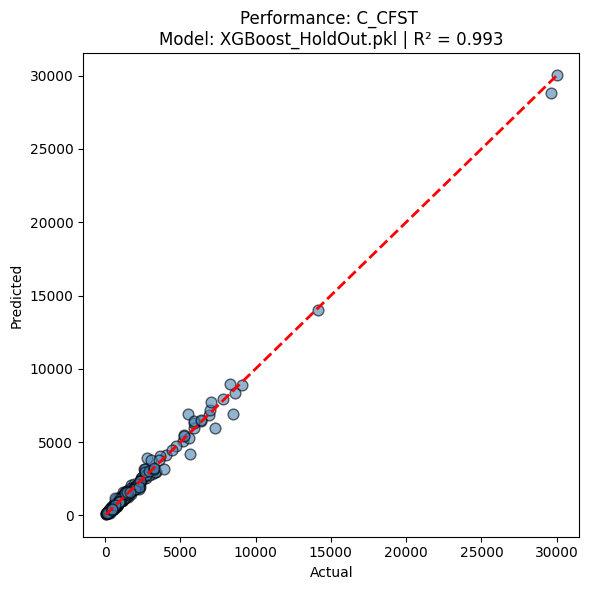

✅ تم الانتهاء بنجاح من: C_CFST
   - المستخدم: XGBoost_HoldOut.pkl
   - طريقة المعالجة: External scaler.pkl
------------------------------


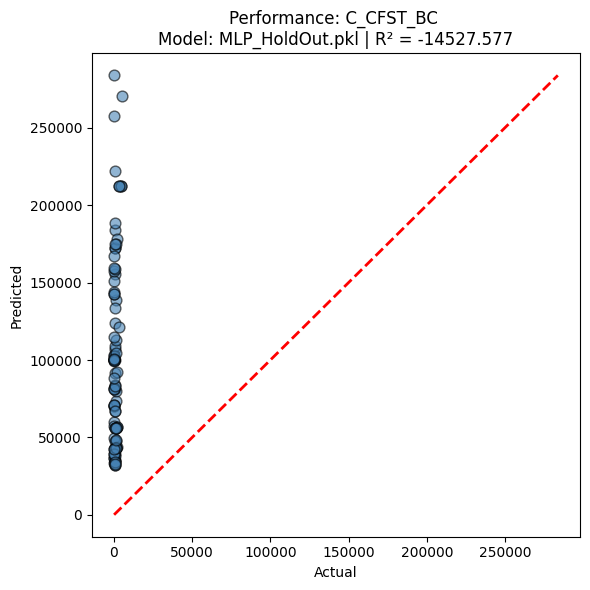

✅ تم الانتهاء بنجاح من: C_CFST_BC
   - المستخدم: MLP_HoldOut.pkl
   - طريقة المعالجة: Internal Pipeline Scaler
------------------------------


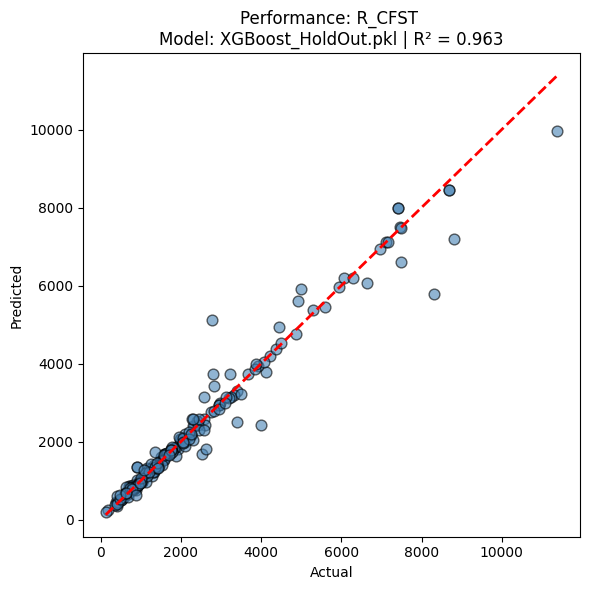

✅ تم الانتهاء بنجاح من: R_CFST
   - المستخدم: XGBoost_HoldOut.pkl
   - طريقة المعالجة: External scaler.pkl
------------------------------


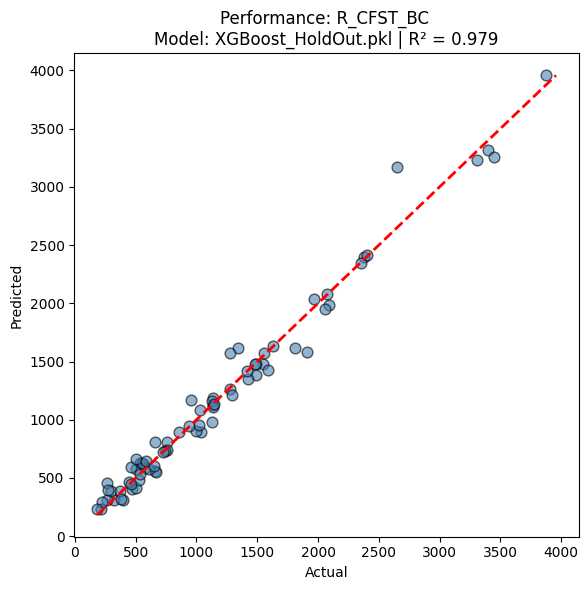

✅ تم الانتهاء بنجاح من: R_CFST_BC
   - المستخدم: XGBoost_HoldOut.pkl
   - طريقة المعالجة: External scaler.pkl
------------------------------


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline # ضروري للتحقق من نوع الموديل

sheets = ["C_CFST", "C_CFST_BC", "R_CFST", "R_CFST_BC"]

for sheet in sheets:
    base_dir = f'/content/drive/MyDrive/Master/Final/{sheet}'

    if not os.path.exists(base_dir):
        print(f"⚠️ المجلد غير موجود: {base_dir}")
        continue

    # البحث عن أي ملف ينتهي بـ HoldOut.pkl
    files = os.listdir(base_dir)
    model_files = [f for f in files if f.endswith('HoldOut.pkl')]

    if not model_files:
        print(f"⚠️ لم يتم العثور على ملف HoldOut في: {sheet}")
        continue

    model_path = os.path.join(base_dir, model_files[0])
    model = joblib.load(model_path)

    # تجهيز البيانات
    X = processed_data[sheet]['X']
    y = processed_data[sheet]['y']
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- المنطق الجديد: التحقق من نوع الموديل ---
    if isinstance(model, Pipeline):
        # الموديل يحتوي على Scaler بداخله (مثل C_CFST_BC)
        y_pred = model.predict(X_test)
        predict_method = "Internal Pipeline Scaler"
    else:
        # الموديل يحتاج سكيلر خارجي (مثل XGBoost)
        scaler_path = os.path.join(base_dir, 'scaler.pkl')
        if not os.path.exists(scaler_path):
            print(f"⚠️ ملف السكيلر مفقود لـ: {sheet}")
            continue
        scaler = joblib.load(scaler_path)
        X_test_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_test_scaled)
        predict_method = "External scaler.pkl"

    # الرسم
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    ax.set_title(f'Performance: {sheet} \nModel: {model_files[0]} | R² = {r2_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    plt.tight_layout()
    plt.show()

    print(f"✅ تم الانتهاء بنجاح من: {sheet}")
    print(f"   - المستخدم: {model_files[0]}")
    print(f"   - طريقة المعالجة: {predict_method}")
    print("-" * 30)

In [ ]:
# ضعي هذا الكود قبل عملية التنبؤ للتأكد من بنية الموديل
from sklearn.pipeline import Pipeline

print(f"نوع الموديل: {type(model)}")

if isinstance(model, Pipeline):
    print("الموديل عبارة عن Pipeline، وهذا يعني أنه يحتوي على Scaler داخله.")
    # تأكدي من الخطوات الموجودة في البايبلاين
    print("خطوات البايبلاين:", model.named_steps.keys())
else:
    print("الموديل ليس Pipeline.")

نوع الموديل: <class 'xgboost.sklearn.XGBRegressor'>
الموديل ليس Pipeline.


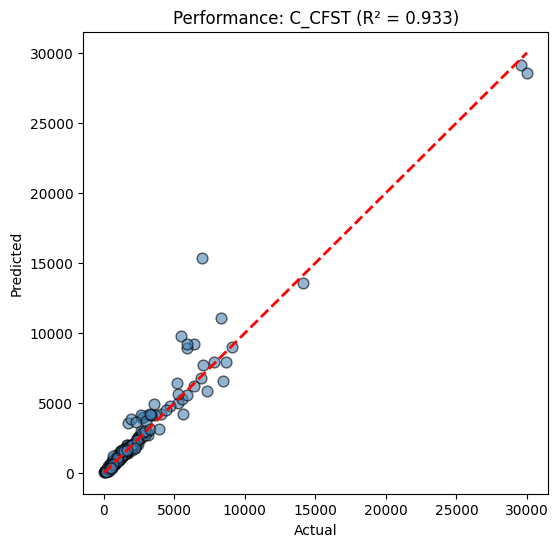

✅ تم الانتهاء من رسم: C_CFST


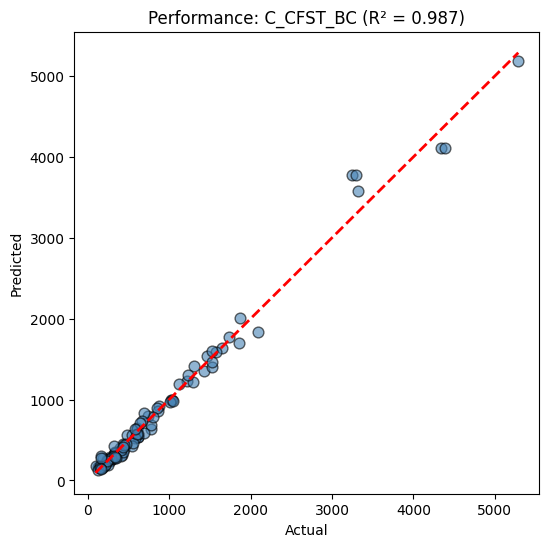

✅ تم الانتهاء من رسم: C_CFST_BC


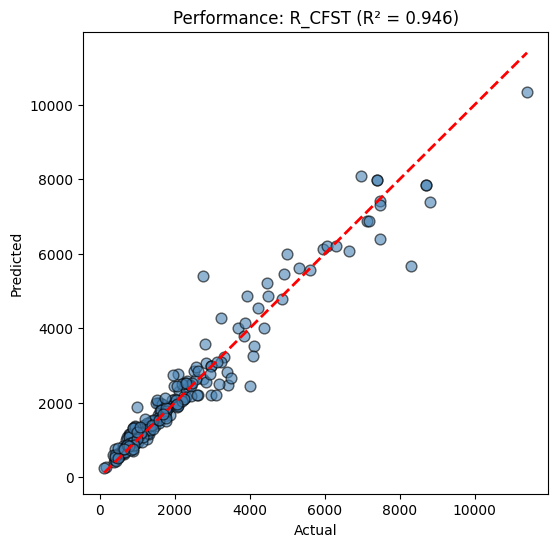

✅ تم الانتهاء من رسم: R_CFST


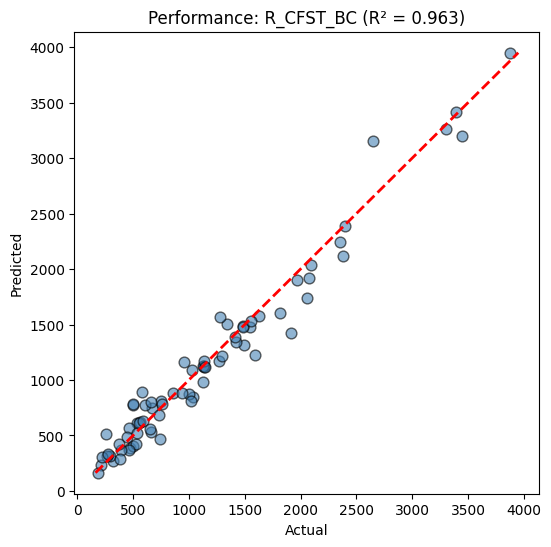

✅ تم الانتهاء من رسم: R_CFST_BC


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import os

# 1. تحميل ملف السكيلرز العام (الذي حفظتيه سابقاً)
artifacts = joblib.load('/content/drive/MyDrive/Master/Final/Preprocessing/preprocessing_artifacts.pkl')

sheets = ["C_CFST", "C_CFST_BC", "R_CFST", "R_CFST_BC"]

for sheet in sheets:
    base_dir = f'/content/drive/MyDrive/Master/Final/{sheet}'

    # تحديد اسم الموديل بناءً على ما وجدناه
    if sheet == 'C_CFST_BC':
        model_filename = 'MLP_HoldOut.pkl'
    else:
        model_filename = 'XGBoost_HoldOut.pkl'

    model_path = os.path.join(base_dir, model_filename)

    # التأكد من وجود الموديل
    if not os.path.exists(model_path):
        print(f"⚠️ الموديل غير موجود: {model_path}")
        continue

    # 2. تحميل الموديل والسكيلر
    model = joblib.load(model_path)
    scaler = artifacts[sheet]['scaler'] # سحب السكيلر الخاص بهذا الشيت من الملف العام

    # التنبؤ
    X = processed_data[sheet]['X']
    y = processed_data[sheet]['y']
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)

    # الرسم
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=60, color='steelblue')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    ax.set_title(f'Performance: {sheet} (R² = {r2_score(y_test, y_pred):.3f})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    plt.show()
    print(f"✅ تم الانتهاء من رسم: {sheet}")

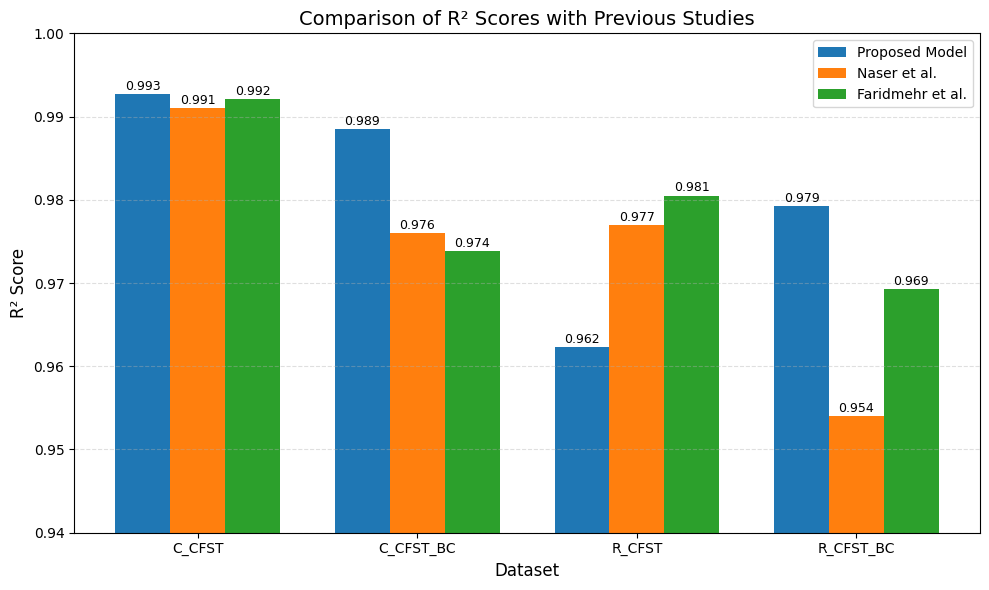

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ['C_CFST', 'C_CFST_BC', 'R_CFST', 'R_CFST_BC']

our_results = [0.9927, 0.9885, 0.9623, 0.9792]
naser = [0.9910, 0.9760, 0.9770, 0.9540]
faridmehr = [0.9921, 0.9738, 0.9805, 0.9693]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, our_results, width,
                label='Proposed Model')
bars2 = plt.bar(x, naser, width,
                label='Naser et al.')
bars3 = plt.bar(x + width, faridmehr, width,
                label='Faridmehr et al.')

plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.title('Comparison of R² Scores with Previous Studies', fontsize=14)
plt.xticks(x, datasets)
plt.ylim(0.94, 1.00)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0005,
            f'{height:.3f}',
            ha='center',
            fontsize=9
        )

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('comparison_with_previous_studies.png', dpi=300)
plt.show()

# **Nn**
